# NxS Project — Polished Visualization Notebook

This notebook is designed for **presentation and report figures**.

It focuses on:
- cleaner plots,
- more comparative visuals,
- phase-wise summaries,
- network visuals that are readable in slides,
- tables that can be shown directly in a meeting.

Run the notebook from the **project root folder** so the file paths work correctly.

## 0. Imports and paths

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.ticker import FuncFormatter

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROJECT_ROOT = Path(".")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"
NETWORK_DIR = OUTPUT_DIR / "network_outputs"

ACLED_FILE = DATA_DIR / "ACLED Data_2026-04-10.csv"
GED_FILES = [
    DATA_DIR / "GEDEvent_v25_01_25_12.csv",
    DATA_DIR / "GEDEvent_v26_0_1.csv",
    DATA_DIR / "GEDEvent_v26_0_2.csv",
]

HARMONIZED_FILE = OUTPUT_DIR / "project_ready_conflict_harmonized_v2.csv"
PHASE2_FILE = OUTPUT_DIR / "conflict_filtered_phase2_core_v2.csv"
PHASE3_FILE = OUTPUT_DIR / "conflict_phase3_segmented_v2.csv"

EDGE_OVERALL_FILE = NETWORK_DIR / "actor_actor_edges_overall.csv"
EDGE_BY_PHASE_FILE = NETWORK_DIR / "actor_actor_edges_by_phase.csv"
NODE_METRICS_OVERALL_FILE = NETWORK_DIR / "actor_network_node_metrics_overall.csv"
NODE_METRICS_BY_PHASE_FILE = NETWORK_DIR / "actor_network_node_metrics_by_phase.csv"
PHASE_SUMMARY_FILE = NETWORK_DIR / "actor_network_summary_by_phase.csv"
PHASE_MODULARITY_FILE = NETWORK_DIR / "actor_community_modularity_by_phase.csv"
OVERALL_BRIDGE_FILE = NETWORK_DIR / "bridge_actors_overall_cleaned.csv"
PHASE_BRIDGE_FILE = NETWORK_DIR / "top10_bridge_actors_by_phase.csv"
COMMUNITY_SUMMARY_OVERALL_FILE = NETWORK_DIR / "actor_community_summary_overall.csv"
COMMUNITY_SUMMARY_PHASE_FILE = NETWORK_DIR / "actor_community_summary_by_phase.csv"

for p in [DATA_DIR, OUTPUT_DIR, NETWORK_DIR]:
    print(p.resolve(), "exists =", p.exists())

F:\NxS Project\data exists = True
F:\NxS Project\output exists = True
F:\NxS Project\output\network_outputs exists = True


## 1. Load data

In [2]:
acled = pd.read_csv(ACLED_FILE, low_memory=False)
ged_list = [pd.read_csv(f, low_memory=False) for f in GED_FILES]

harmonized = pd.read_csv(HARMONIZED_FILE, low_memory=False)
phase2 = pd.read_csv(PHASE2_FILE, low_memory=False)
phase3 = pd.read_csv(PHASE3_FILE, low_memory=False)

overall_edges = pd.read_csv(EDGE_OVERALL_FILE, low_memory=False)
phase_edges = pd.read_csv(EDGE_BY_PHASE_FILE, low_memory=False)
overall_node_metrics = pd.read_csv(NODE_METRICS_OVERALL_FILE, low_memory=False)
phase_node_metrics = pd.read_csv(NODE_METRICS_BY_PHASE_FILE, low_memory=False)
phase_summary = pd.read_csv(PHASE_SUMMARY_FILE, low_memory=False)
phase_modularity = pd.read_csv(PHASE_MODULARITY_FILE, low_memory=False)
overall_bridge = pd.read_csv(OVERALL_BRIDGE_FILE, low_memory=False)
phase_bridge = pd.read_csv(PHASE_BRIDGE_FILE, low_memory=False)
community_overall = pd.read_csv(COMMUNITY_SUMMARY_OVERALL_FILE, low_memory=False)
community_phase = pd.read_csv(COMMUNITY_SUMMARY_PHASE_FILE, low_memory=False)

print("ACLED:", acled.shape)
for f, df in zip(GED_FILES, ged_list):
    print(f.name, df.shape)
print("Harmonized:", harmonized.shape)
print("Phase 2:", phase2.shape)
print("Phase 3:", phase3.shape)
print("Overall edges:", overall_edges.shape)
print("Phase edges:", phase_edges.shape)

ACLED: (605715, 32)
GEDEvent_v25_01_25_12.csv (28396, 49)
GEDEvent_v26_0_1.csv (1727, 49)
GEDEvent_v26_0_2.csv (1298, 49)
Harmonized: (637125, 30)
Phase 2: (546300, 30)
Phase 3: (546300, 32)
Overall edges: (6625, 9)
Phase edges: (8330, 9)


## 2. Executive summary table

In [3]:
summary = pd.DataFrame({
    "Dataset / Output": [
        "Raw ACLED",
        "GED 2025",
        "GED v26_0_1",
        "GED v26_0_2",
        "Harmonized v2",
        "Strict Phase 2",
        "Phase 3 Segmented"
    ],
    "Rows": [
        len(acled),
        len(ged_list[0]),
        len(ged_list[1]),
        len(ged_list[2]),
        len(harmonized),
        len(phase2),
        len(phase3)
    ],
    "Columns": [
        acled.shape[1],
        ged_list[0].shape[1],
        ged_list[1].shape[1],
        ged_list[2].shape[1],
        harmonized.shape[1],
        phase2.shape[1],
        phase3.shape[1]
    ]
})
display(summary)

,Dataset / Output,Rows,Columns
0,Raw ACLED,605715,32
1,GED 2025,28396,49
2,GED v26_0_1,1727,49
3,GED v26_0_2,1298,49
4,Harmonized v2,637125,30
5,Strict Phase 2,546300,30
6,Phase 3 Segmented,546300,32


## 3. Raw data visuals
These figures show what the data looked like before preprocessing.

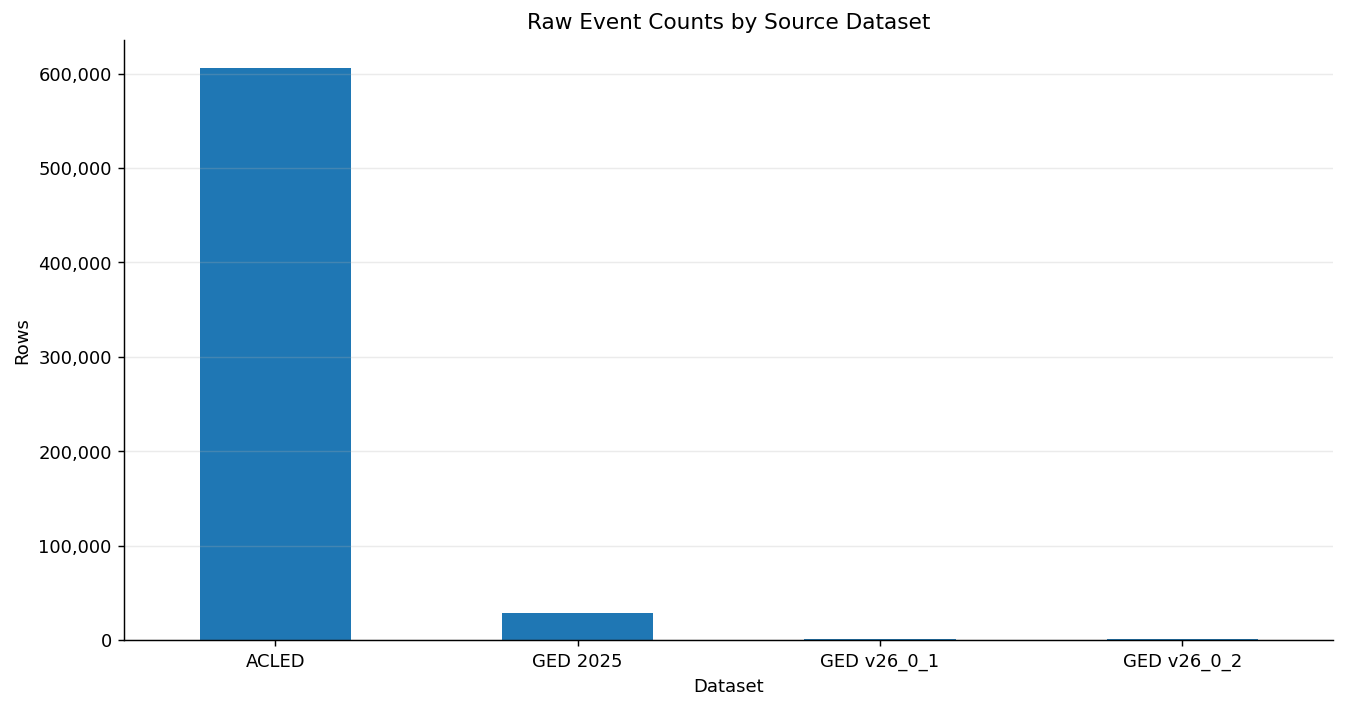

In [4]:
# Raw source counts
source_counts = pd.Series({
    "ACLED": len(acled),
    "GED 2025": len(ged_list[0]),
    "GED v26_0_1": len(ged_list[1]),
    "GED v26_0_2": len(ged_list[2]),
})
ax = source_counts.plot(kind="bar", title="Raw Event Counts by Source Dataset")
ax.set_xlabel("Dataset")
ax.set_ylabel("Rows")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()

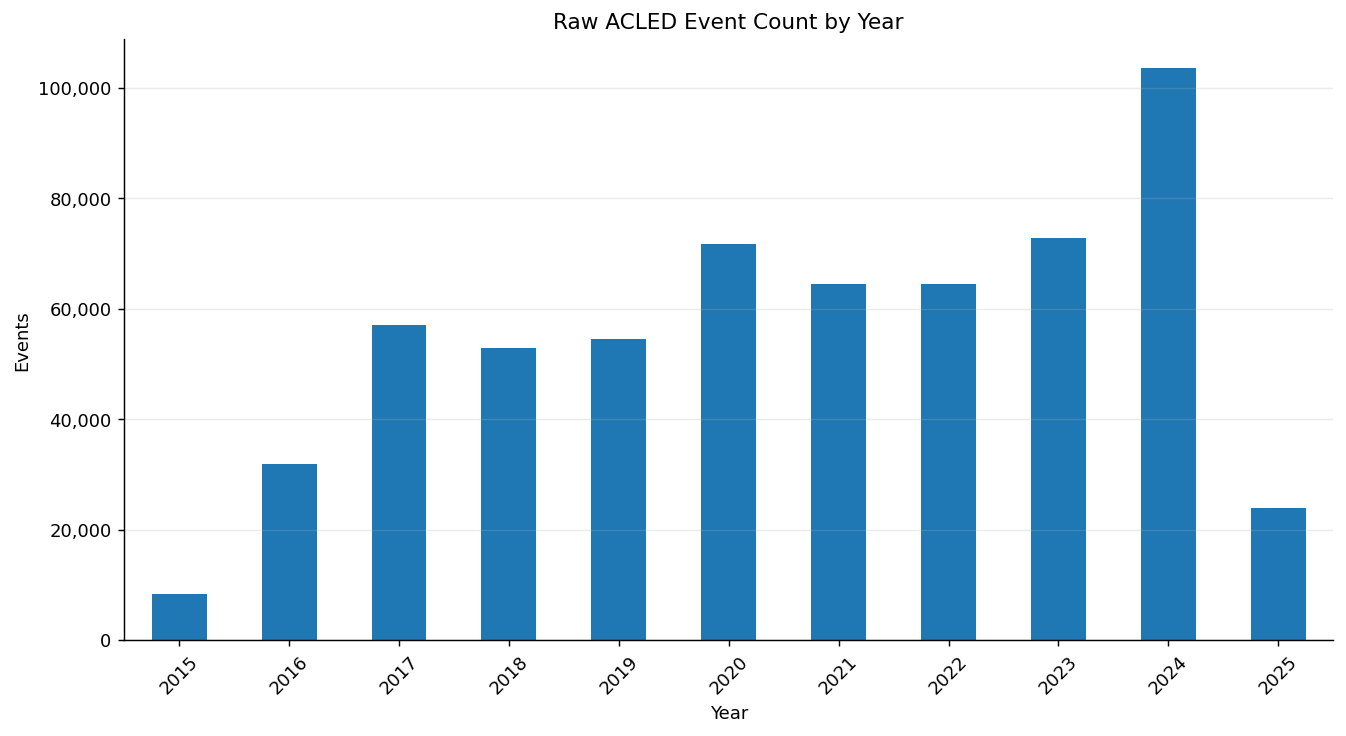

In [5]:
# Raw ACLED yearly distribution
acled_year = pd.to_numeric(acled.get("year"), errors="coerce").value_counts().sort_index()
ax = acled_year.plot(kind="bar", title="Raw ACLED Event Count by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Events")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.show()

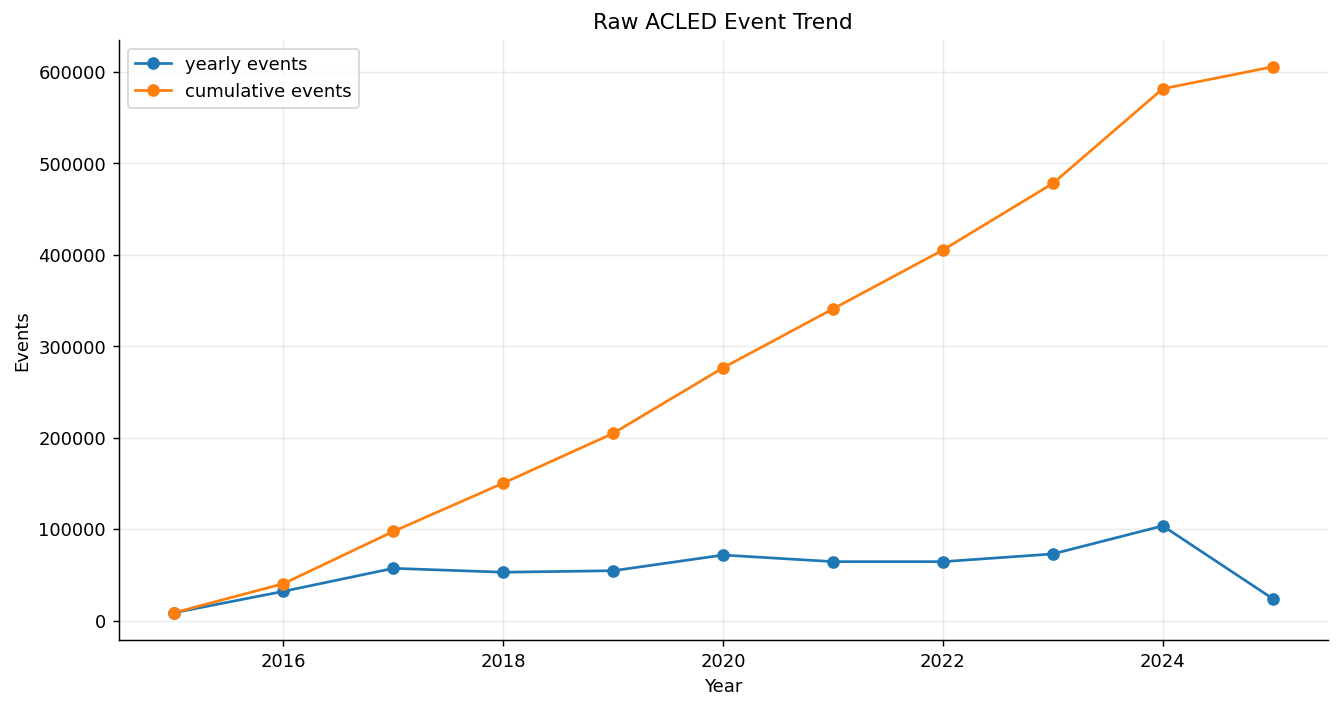

In [6]:
# Raw ACLED cumulative trend
year_df = acled_year.reset_index()
year_df.columns = ["year", "events"]
year_df["cumulative_events"] = year_df["events"].cumsum()

plt.figure(figsize=(12,6))
plt.plot(year_df["year"], year_df["events"], marker="o", label="yearly events")
plt.plot(year_df["year"], year_df["cumulative_events"], marker="o", label="cumulative events")
plt.title("Raw ACLED Event Trend")
plt.xlabel("Year")
plt.ylabel("Events")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

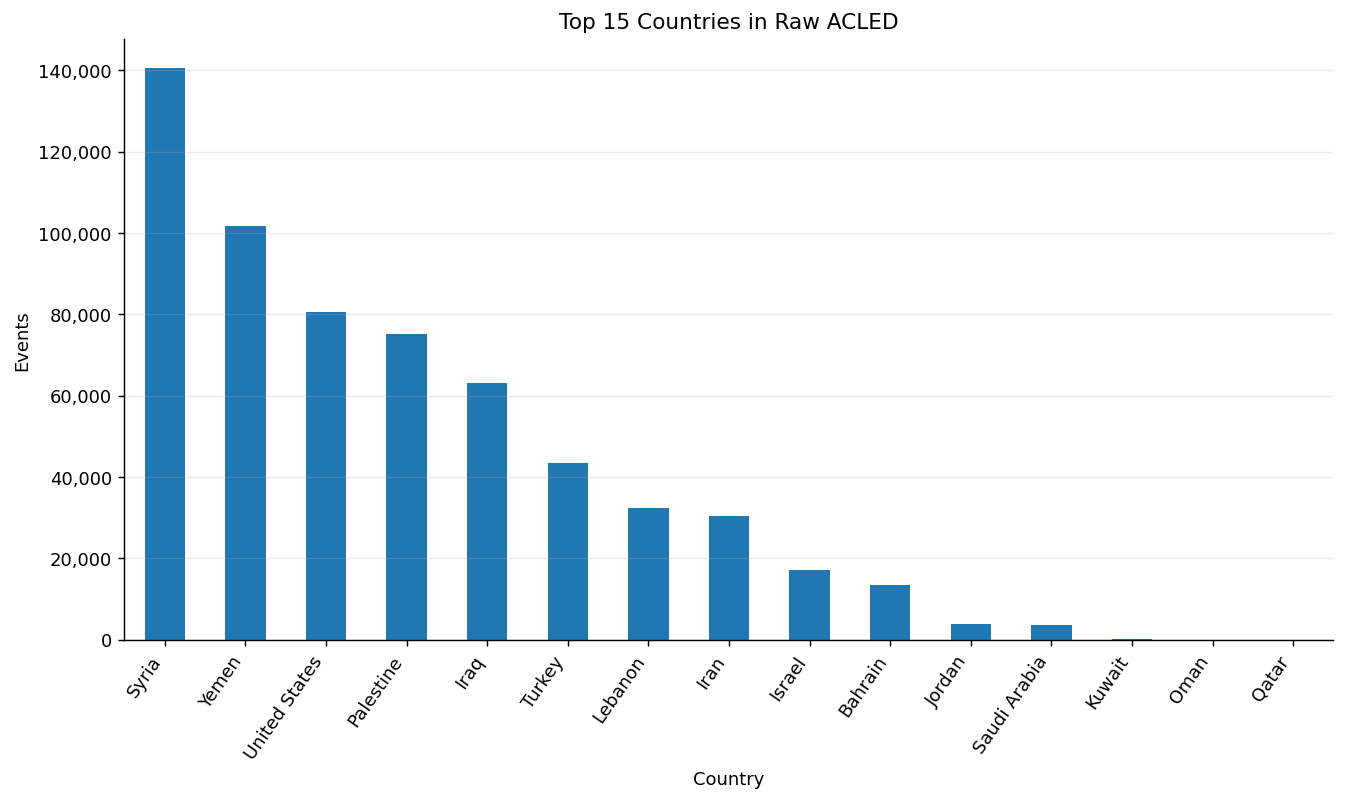

In [7]:
# Top countries in raw ACLED
top_raw_countries = acled["country"].value_counts().head(15)
ax = top_raw_countries.plot(kind="bar", title="Top 15 Countries in Raw ACLED")
ax.set_xlabel("Country")
ax.set_ylabel("Events")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
plt.xticks(rotation=55, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.show()

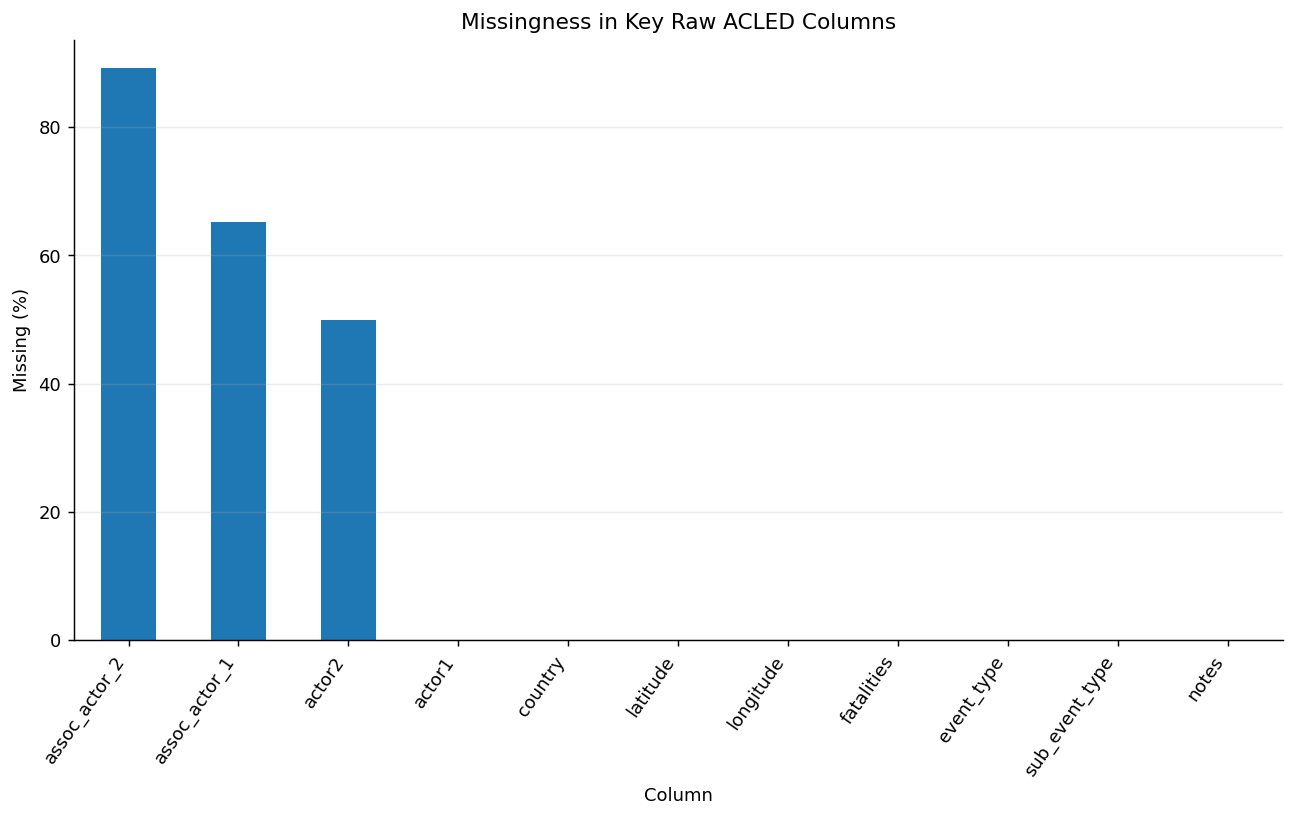

In [8]:
# Missingness in key raw ACLED columns
raw_key_cols = [
    "actor1", "assoc_actor_1", "actor2", "assoc_actor_2",
    "country", "latitude", "longitude", "fatalities",
    "event_type", "sub_event_type", "notes"
]
raw_key_cols = [c for c in raw_key_cols if c in acled.columns]
raw_missing = acled[raw_key_cols].isna().mean().sort_values(ascending=False) * 100

ax = raw_missing.plot(kind="bar", title="Missingness in Key Raw ACLED Columns")
ax.set_xlabel("Column")
ax.set_ylabel("Missing (%)")
plt.xticks(rotation=55, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.show()

## 4. Preprocessing visuals
These explain what changed after harmonization, filtering, and phase segmentation.

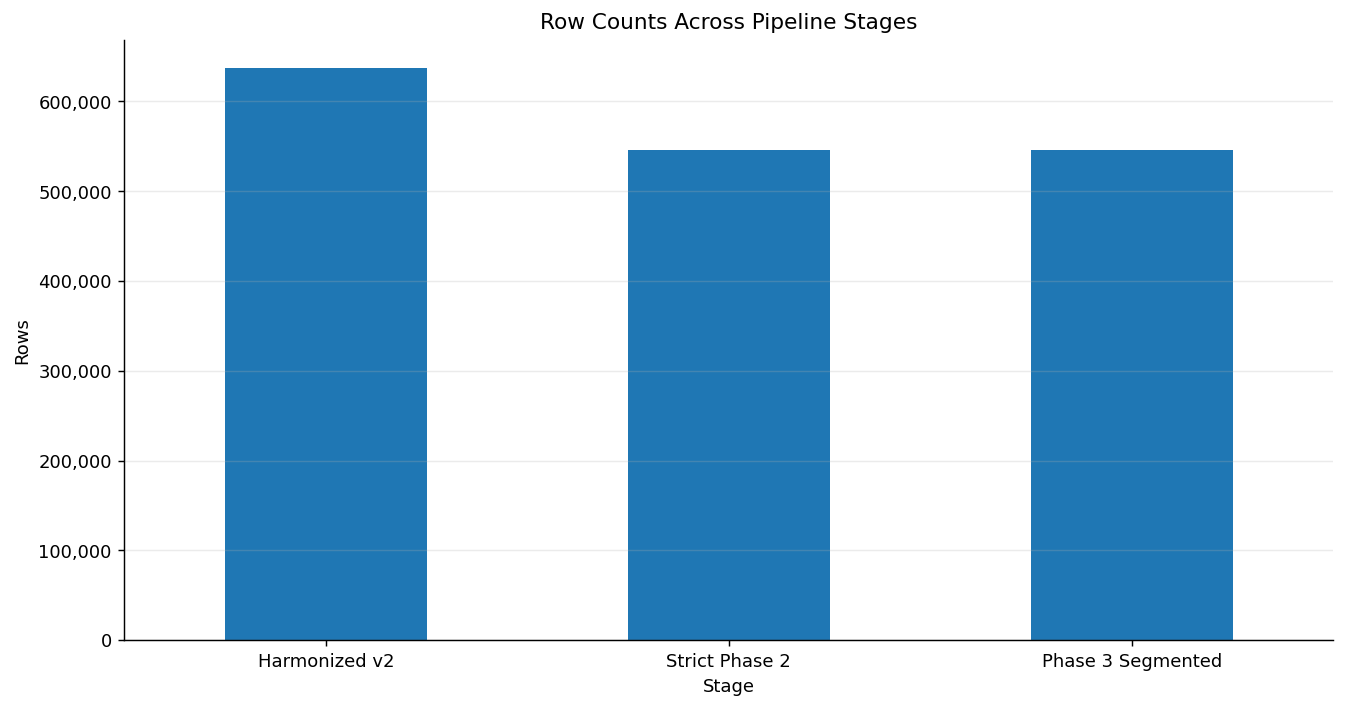

In [9]:
# Row counts across stages
stage_counts = pd.Series({
    "Harmonized v2": len(harmonized),
    "Strict Phase 2": len(phase2),
    "Phase 3 Segmented": len(phase3),
})
ax = stage_counts.plot(kind="bar", title="Row Counts Across Pipeline Stages")
ax.set_xlabel("Stage")
ax.set_ylabel("Rows")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()

,stage,rows,pct_of_harmonized
0,Harmonized v2,637125,100.000000
1,Strict Phase 2,546300,85.744556
2,Phase 3 Segmented,546300,85.744556


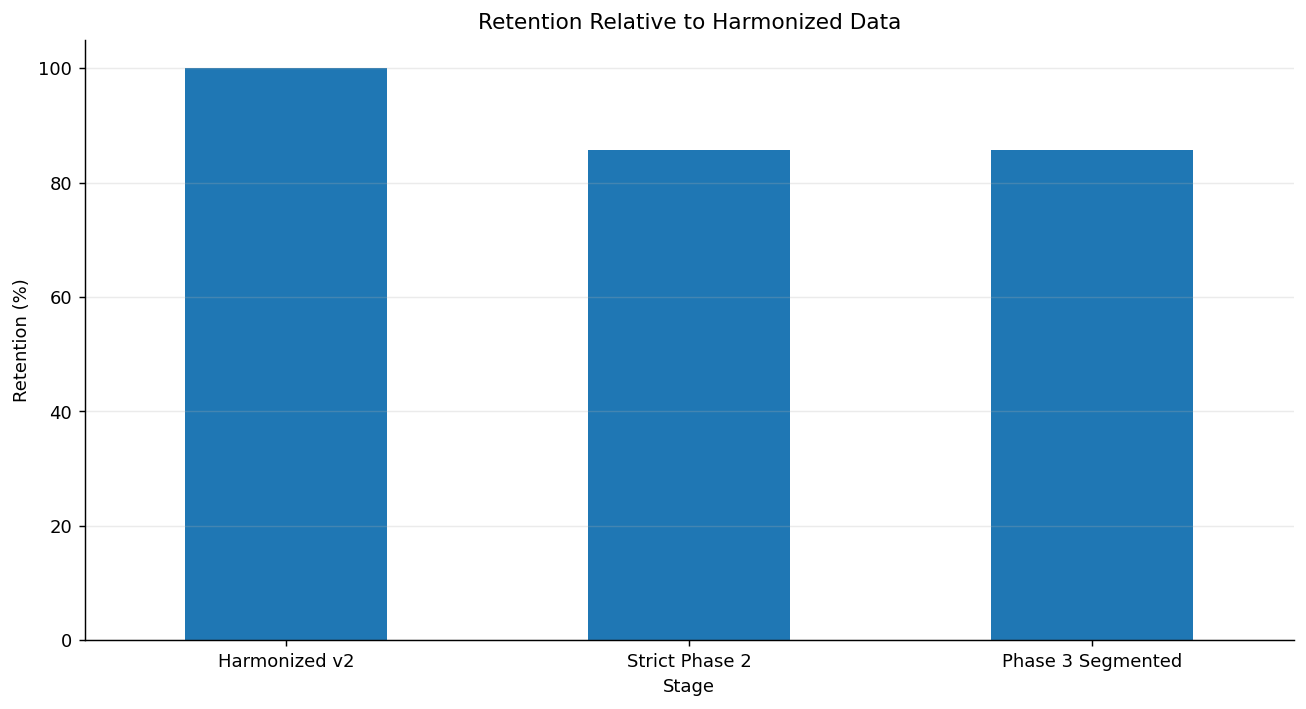

In [10]:
# Retention percentage across stages
retention = pd.DataFrame({
    "stage": ["Harmonized v2", "Strict Phase 2", "Phase 3 Segmented"],
    "rows": [len(harmonized), len(phase2), len(phase3)]
})
retention["pct_of_harmonized"] = 100 * retention["rows"] / retention["rows"].iloc[0]
display(retention)

ax = retention.set_index("stage")["pct_of_harmonized"].plot(
    kind="bar", title="Retention Relative to Harmonized Data"
)
ax.set_xlabel("Stage")
ax.set_ylabel("Retention (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()

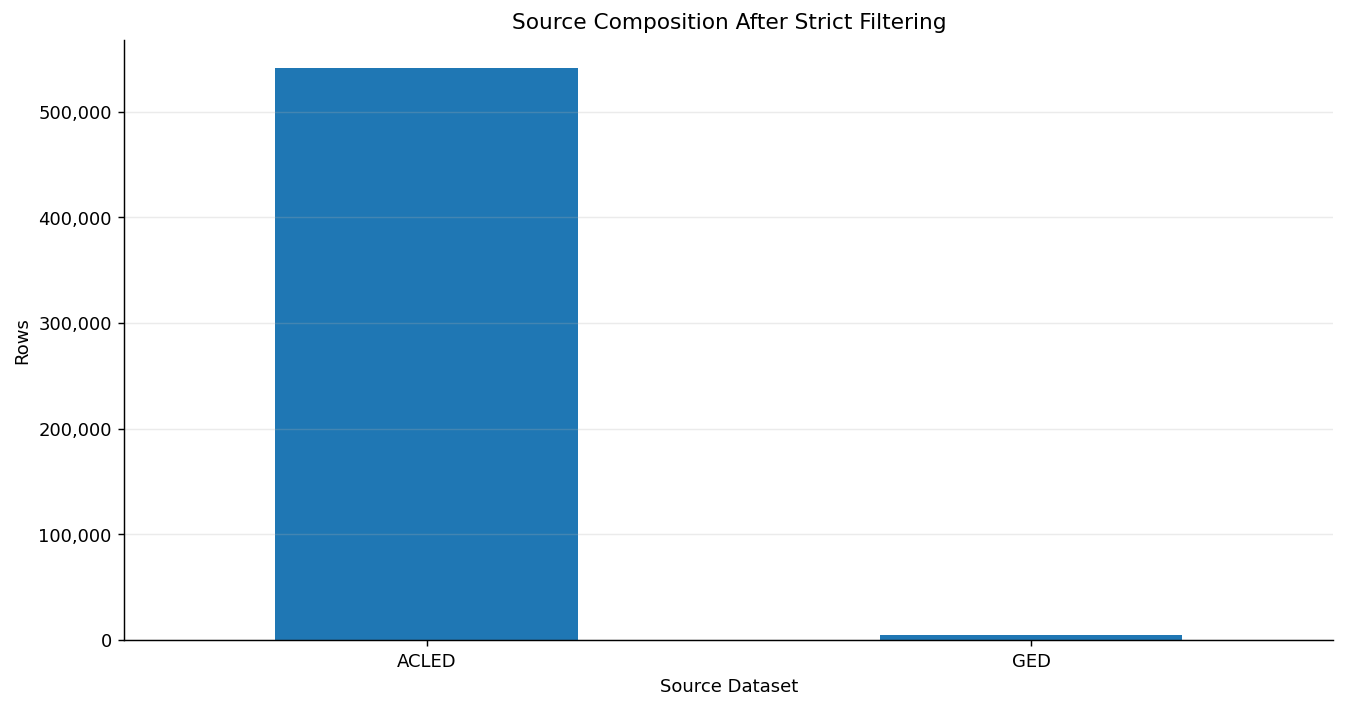

In [11]:
# Source composition after strict filtering
ax = phase2["source_dataset"].value_counts().plot(
    kind="bar", title="Source Composition After Strict Filtering"
)
ax.set_xlabel("Source Dataset")
ax.set_ylabel("Rows")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()

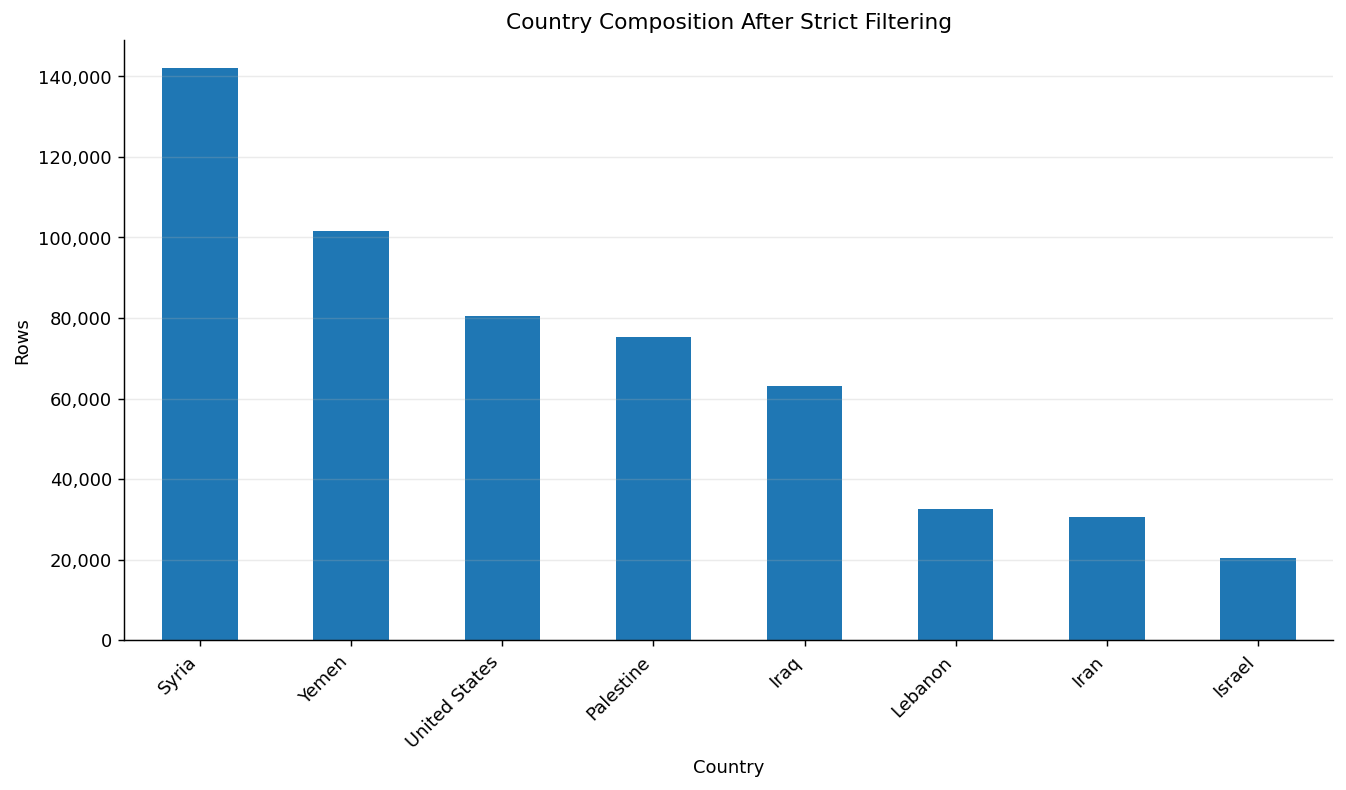

In [12]:
# Country composition after strict filtering
ax = phase2["country"].value_counts().plot(
    kind="bar", title="Country Composition After Strict Filtering"
)
ax.set_xlabel("Country")
ax.set_ylabel("Rows")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.show()

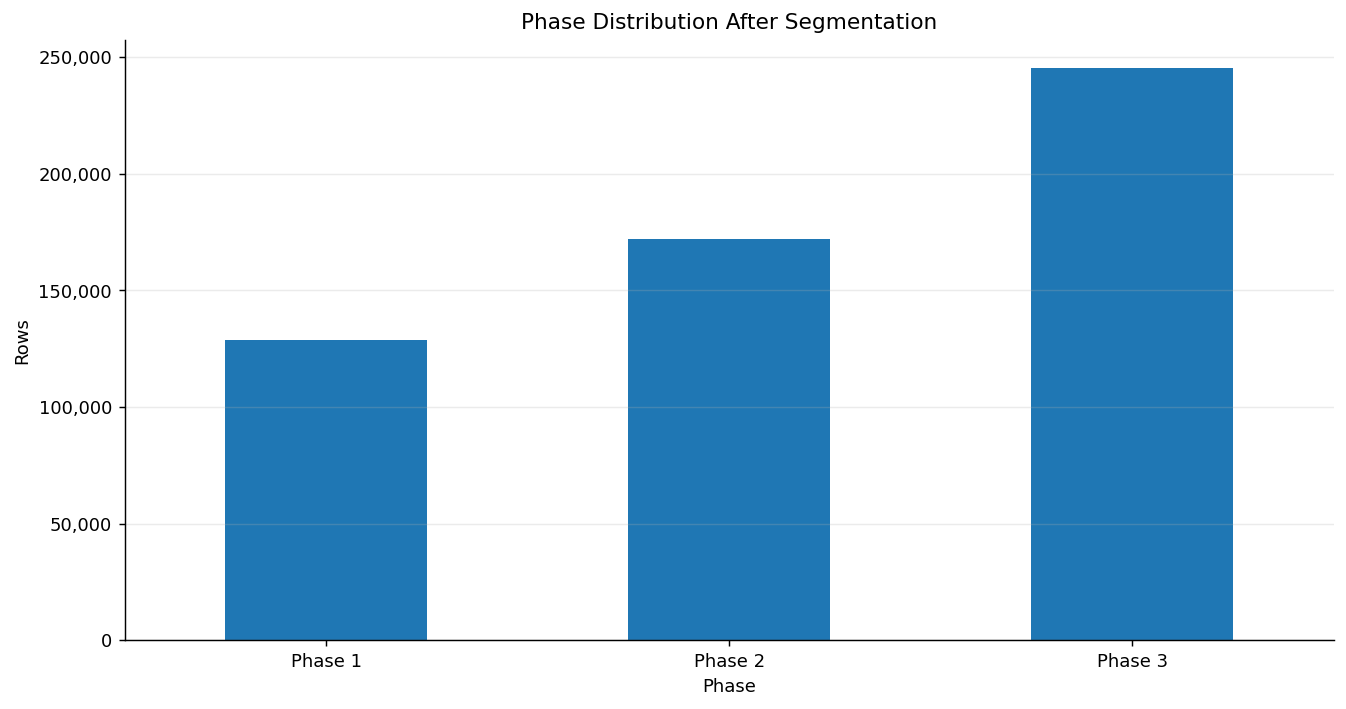

In [13]:
# Phase distribution
ax = phase3["phase"].value_counts().sort_index().plot(
    kind="bar", title="Phase Distribution After Segmentation"
)
ax.set_xlabel("Phase")
ax.set_ylabel("Rows")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()

,raw_acled_missing_pct,harmonized_missing_pct
assoc_actor_2,89.167678,89.701707
assoc_actor_1,65.258909,66.971630
actor2,49.915059,47.454267
actor1,0.000000,0.000000
country,0.000000,0.000000
latitude,0.000000,0.000000
longitude,0.000000,0.000000
fatalities,0.000000,0.000000
event_type,0.000000,0.000000
sub_event_type,0.000000,0.000000


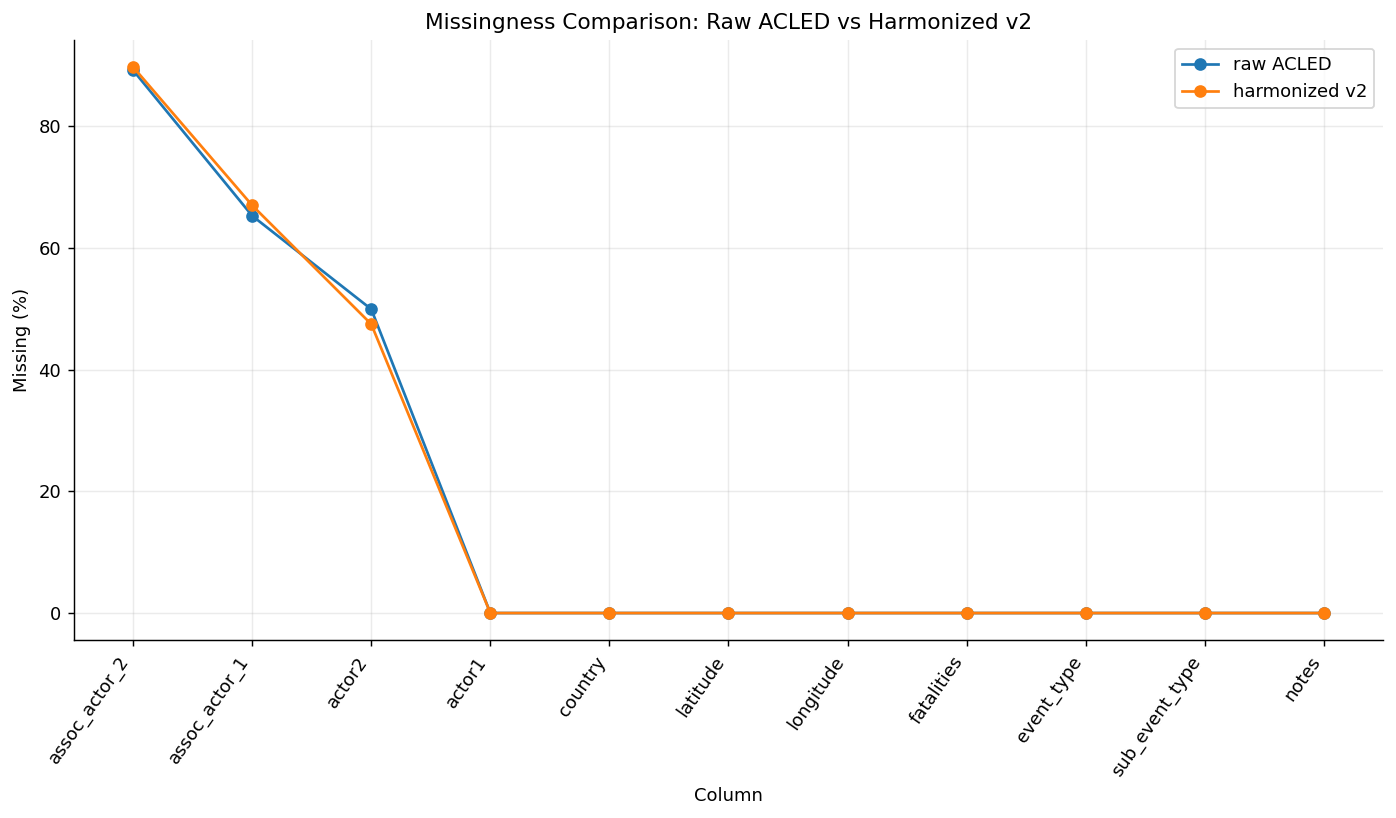

In [14]:
# Missingness comparison: raw vs harmonized
harm_key_cols = [
    "actor1", "assoc_actor_1", "actor2", "assoc_actor_2",
    "country", "latitude", "longitude", "fatalities",
    "event_type", "sub_event_type", "notes"
]
harm_key_cols = [c for c in harm_key_cols if c in harmonized.columns]
common_cols = [c for c in raw_key_cols if c in harm_key_cols]

missing_compare = pd.DataFrame({
    "raw_acled_missing_pct": acled[common_cols].isna().mean() * 100,
    "harmonized_missing_pct": harmonized[common_cols].isna().mean() * 100,
}).sort_values("raw_acled_missing_pct", ascending=False)

display(missing_compare)

plt.figure(figsize=(13,6))
plt.plot(missing_compare.index, missing_compare["raw_acled_missing_pct"], marker="o", label="raw ACLED")
plt.plot(missing_compare.index, missing_compare["harmonized_missing_pct"], marker="o", label="harmonized v2")
plt.title("Missingness Comparison: Raw ACLED vs Harmonized v2")
plt.xlabel("Column")
plt.ylabel("Missing (%)")
plt.xticks(rotation=55, ha="right")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

phase,Phase 1,Phase 2,Phase 3
country,,,
Iran,7545,9284,13660
Iraq,19487,17632,26101
Israel,1439,4159,14831
Lebanon,2257,9804,20594
Palestine,8718,18041,48523
Syria,52293,43346,46407
United States,0,37336,43197
Yemen,37088,32611,31947


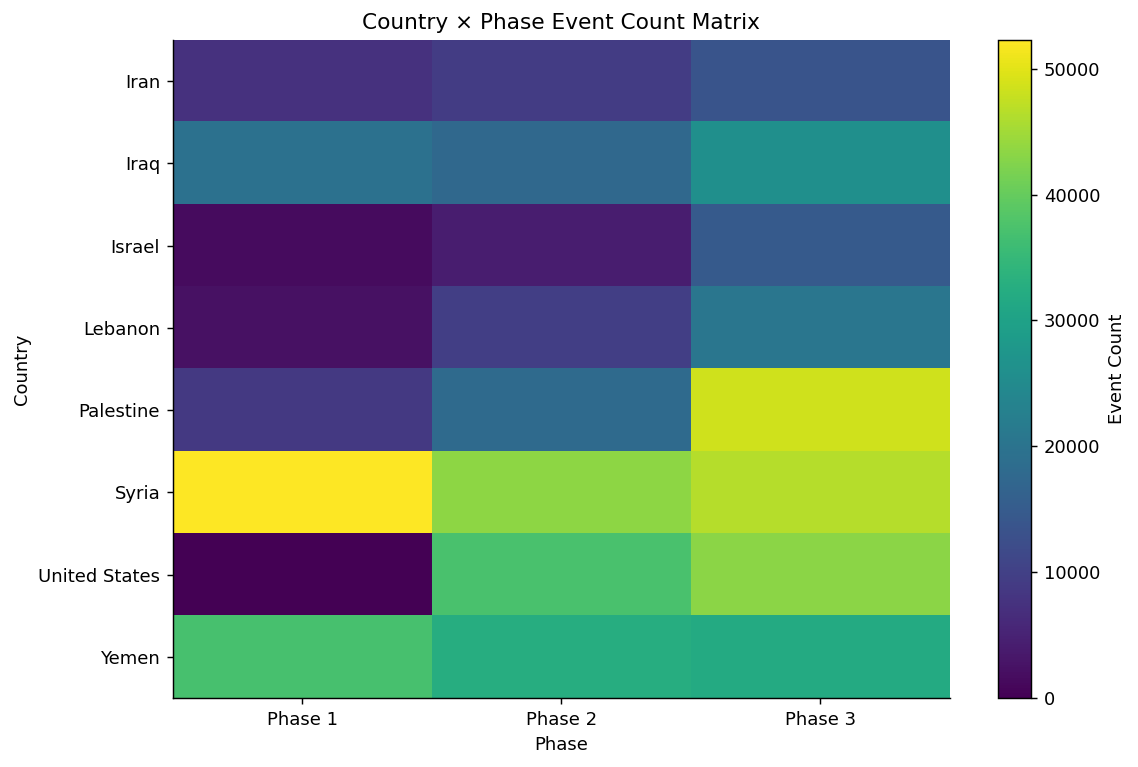

In [15]:
# Country x phase heatmap-like matrix
country_phase = pd.crosstab(phase3["country"], phase3["phase"])
display(country_phase)

plt.figure(figsize=(9,6))
plt.imshow(country_phase.values, aspect="auto")
plt.title("Country × Phase Event Count Matrix")
plt.xlabel("Phase")
plt.ylabel("Country")
plt.xticks(range(len(country_phase.columns)), country_phase.columns)
plt.yticks(range(len(country_phase.index)), country_phase.index)
plt.colorbar(label="Event Count")
plt.tight_layout()
plt.show()

## 5. Phase-wise network metrics
These are the core quantitative figures for the report.

In [16]:
phase_compare = phase_summary.merge(
    phase_modularity[["phase", "communities", "modularity"]],
    on="phase",
    how="left"
)
phase_order = {"Phase 1": 1, "Phase 2": 2, "Phase 3": 3}
phase_compare["phase_order"] = phase_compare["phase"].map(phase_order)
phase_compare = phase_compare.sort_values("phase_order")
display(phase_compare)

,nodes,edges,density,connected_components,largest_component_size,average_clustering,phase,communities,modularity,phase_order
0,754,1893,0.006668,48,652,0.000536,Phase 1,54,0.640777,1
1,1111,2455,0.003981,107,883,0.000253,Phase 2,125,0.727473,2
2,1628,3363,0.002539,156,1290,0.000128,Phase 3,179,0.693744,3


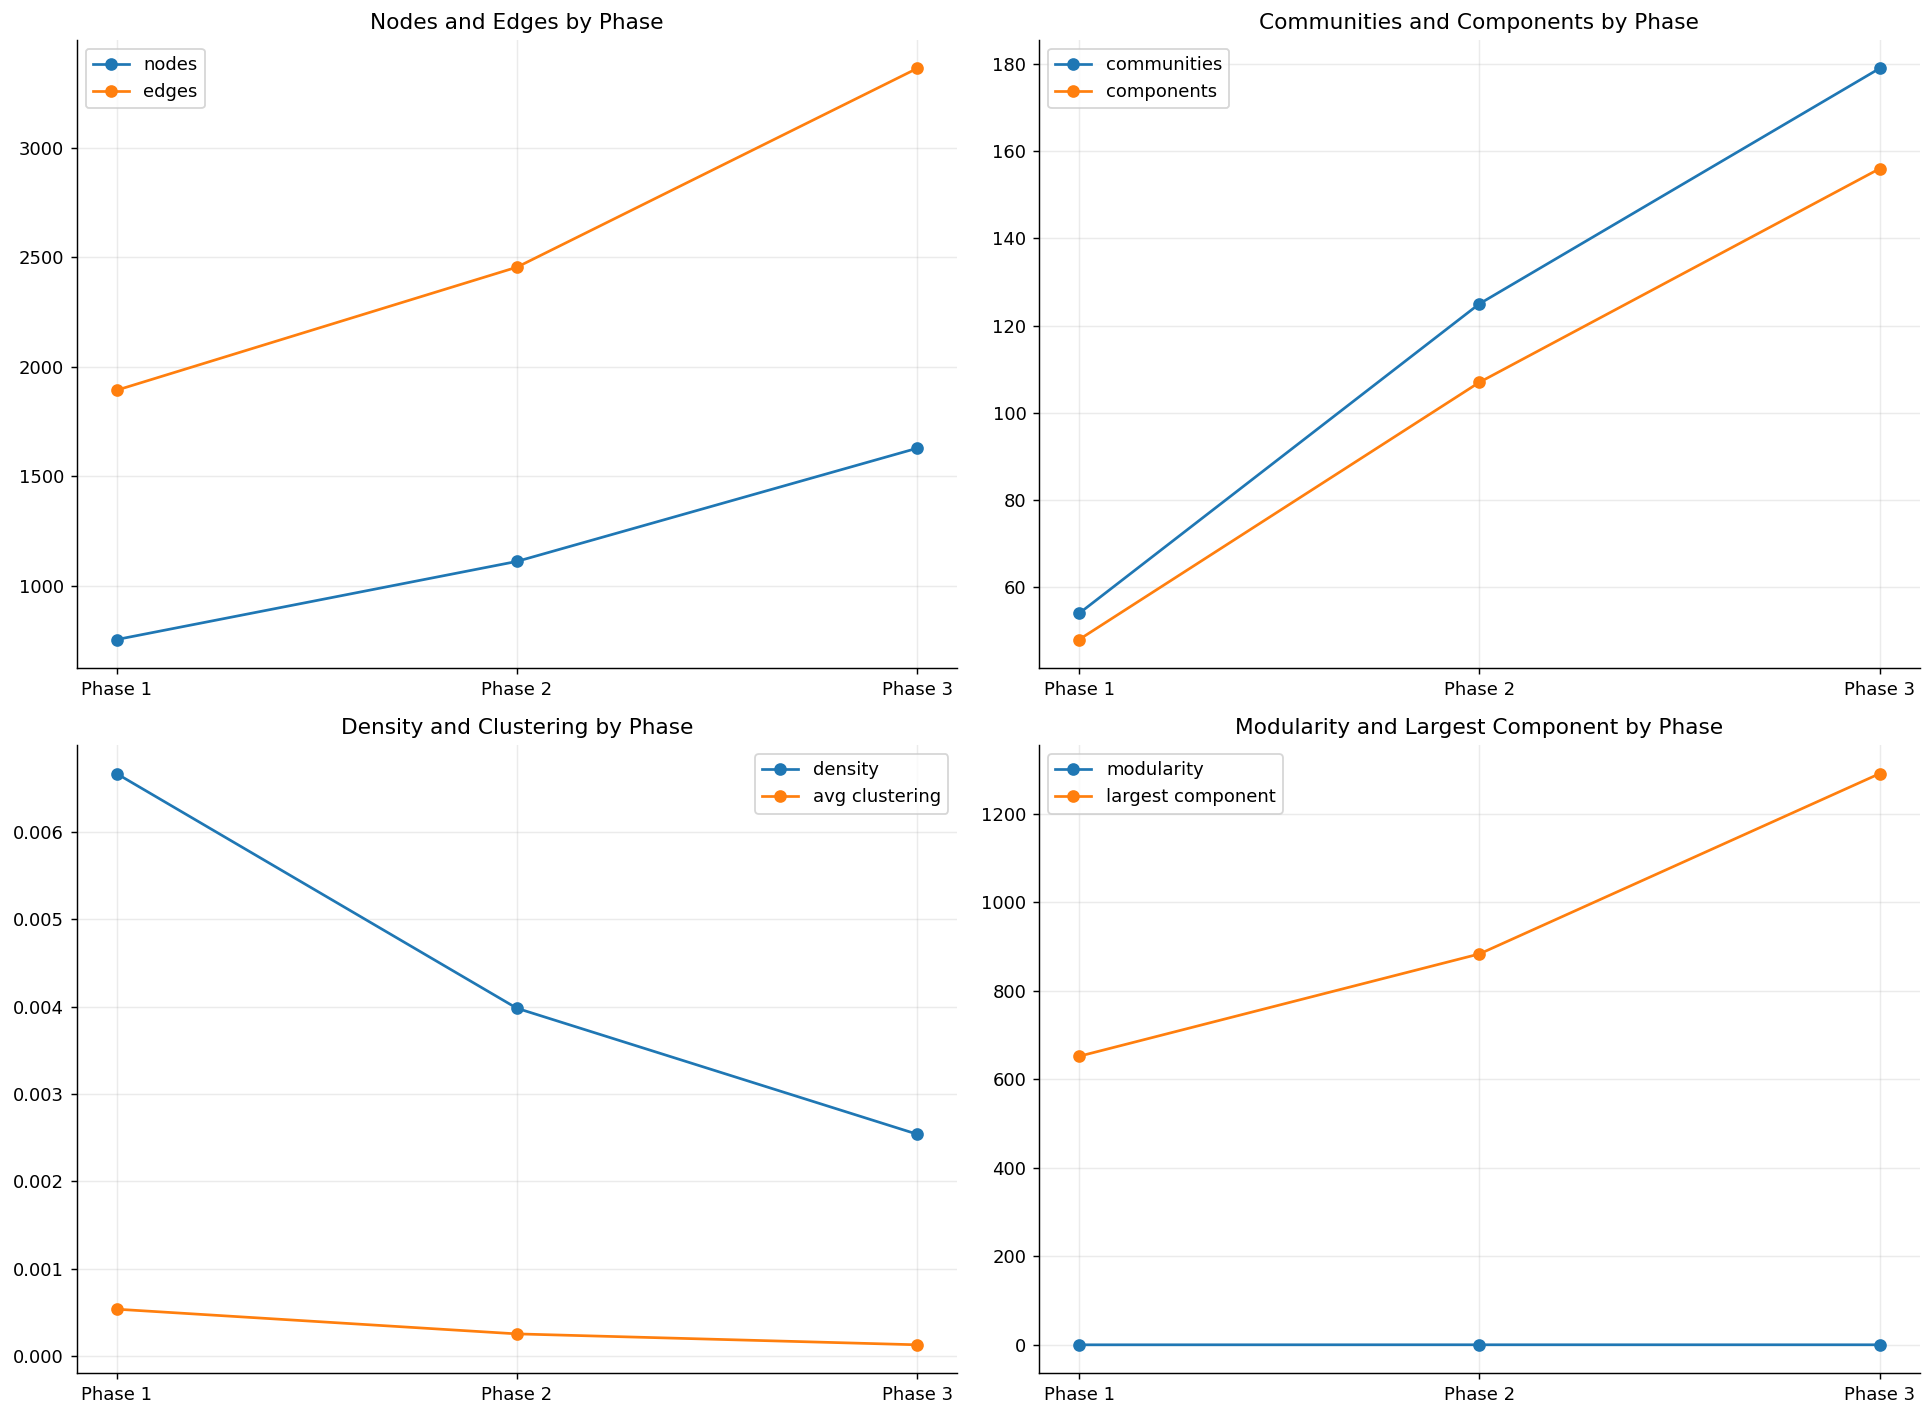

In [17]:
fig = plt.figure(figsize=(15, 11))

plt.subplot(2, 2, 1)
plt.plot(phase_compare["phase"], phase_compare["nodes"], marker="o", label="nodes")
plt.plot(phase_compare["phase"], phase_compare["edges"], marker="o", label="edges")
plt.title("Nodes and Edges by Phase")
plt.legend()
plt.grid(alpha=0.25)

plt.subplot(2, 2, 2)
plt.plot(phase_compare["phase"], phase_compare["communities"], marker="o", label="communities")
plt.plot(phase_compare["phase"], phase_compare["connected_components"], marker="o", label="components")
plt.title("Communities and Components by Phase")
plt.legend()
plt.grid(alpha=0.25)

plt.subplot(2, 2, 3)
plt.plot(phase_compare["phase"], phase_compare["density"], marker="o", label="density")
plt.plot(phase_compare["phase"], phase_compare["average_clustering"], marker="o", label="avg clustering")
plt.title("Density and Clustering by Phase")
plt.legend()
plt.grid(alpha=0.25)

plt.subplot(2, 2, 4)
plt.plot(phase_compare["phase"], phase_compare["modularity"], marker="o", label="modularity")
plt.plot(phase_compare["phase"], phase_compare["largest_component_size"], marker="o", label="largest component")
plt.title("Modularity and Largest Component by Phase")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

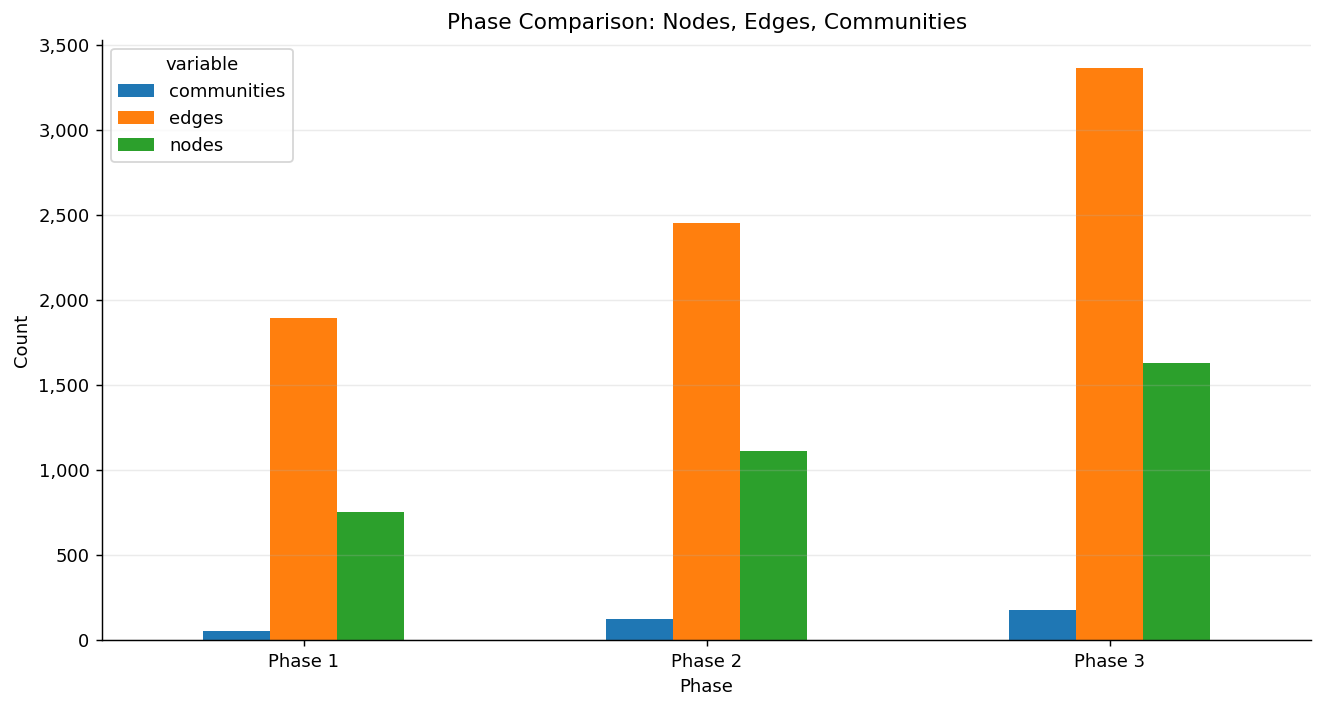

In [18]:
# Extra comparative bars
melted = phase_compare[["phase", "nodes", "edges", "communities"]].melt(id_vars="phase")
pivot_for_plot = melted.pivot(index="phase", columns="variable", values="value")
ax = pivot_for_plot.plot(kind="bar", title="Phase Comparison: Nodes, Edges, Communities")
ax.set_xlabel("Phase")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()

## 6. Actor centrality visuals

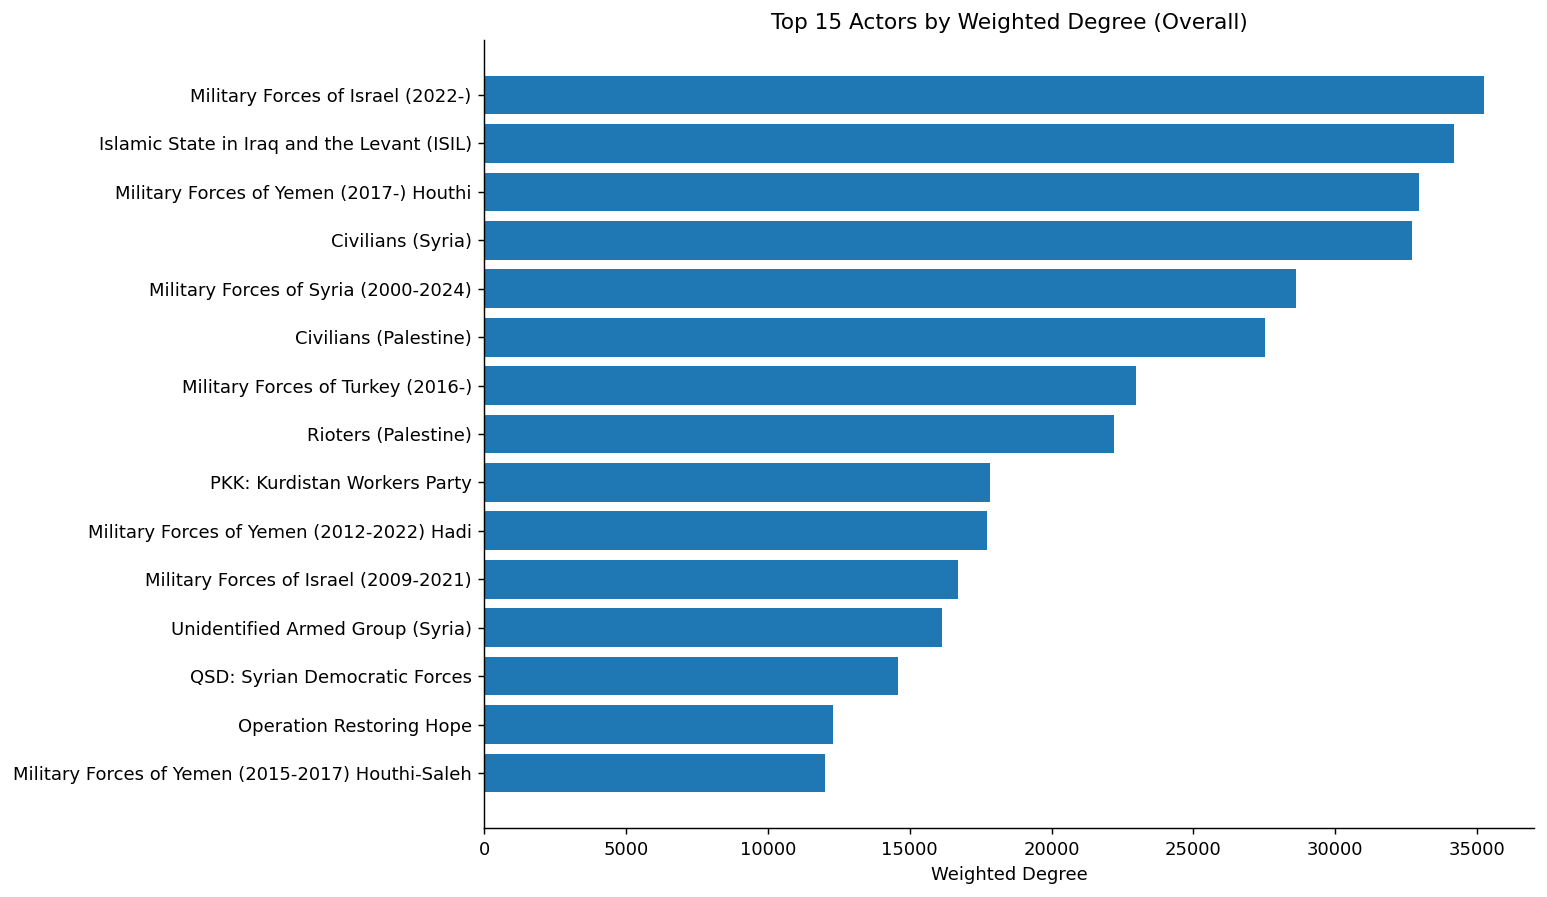

In [19]:
# Top weighted-degree actors overall
top_degree = overall_node_metrics.sort_values(
    ["weighted_degree", "betweenness_centrality"],
    ascending=[False, False]
).head(15)

plt.figure(figsize=(12,7))
plt.barh(top_degree["actor"].iloc[::-1], top_degree["weighted_degree"].iloc[::-1])
plt.title("Top 15 Actors by Weighted Degree (Overall)")
plt.xlabel("Weighted Degree")
plt.tight_layout()
plt.show()

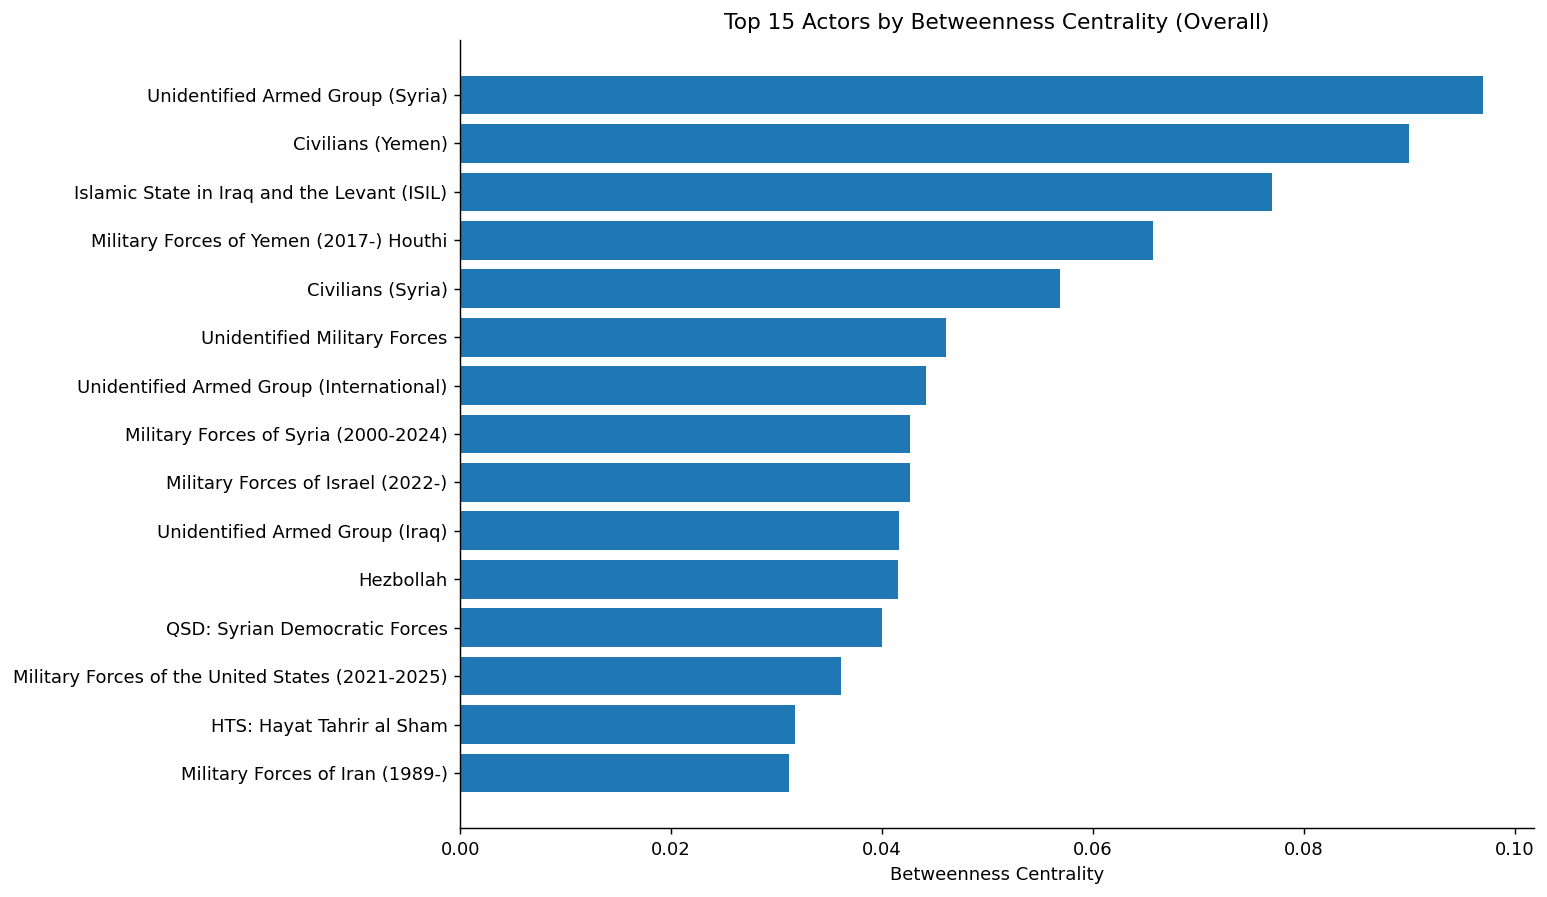

In [20]:
# Top betweenness actors overall
top_bet = overall_node_metrics.sort_values(
    ["betweenness_centrality", "weighted_degree"],
    ascending=[False, False]
).head(15)

plt.figure(figsize=(12,7))
plt.barh(top_bet["actor"].iloc[::-1], top_bet["betweenness_centrality"].iloc[::-1])
plt.title("Top 15 Actors by Betweenness Centrality (Overall)")
plt.xlabel("Betweenness Centrality")
plt.tight_layout()
plt.show()

## 7. Network graphs
For readability, these use only the top actors.

In [21]:
def build_top_network(edge_df, node_metrics_df, top_nodes=80, weight_col="event_count"):
    top_actor_names = node_metrics_df.sort_values(
        ["weighted_degree", "betweenness_centrality"],
        ascending=[False, False]
    )["actor"].head(top_nodes).tolist()

    sub_edges = edge_df[
        edge_df["node_u"].isin(top_actor_names) &
        edge_df["node_v"].isin(top_actor_names)
    ].copy()

    G = nx.Graph()
    for _, row in sub_edges.iterrows():
        u = row["node_u"]
        v = row["node_v"]
        w = row[weight_col]
        if pd.isna(u) or pd.isna(v) or u == v:
            continue
        G.add_edge(u, v, weight=float(w) if pd.notna(w) else 1.0)
    return G

def draw_network(G, title):
    if G.number_of_nodes() == 0:
        print("Empty graph")
        return

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, seed=42, k=0.55)

    weights = [G[u][v].get("weight", 1.0) for u, v in G.edges()]
    max_w = max(weights) if len(weights) else 1
    node_sizes = [220 + 8 * G.degree(n, weight="weight") for n in G.nodes()]
    edge_widths = [0.2 + (w / max_w) * 3 for w in weights] if len(weights) else []

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=0.82)
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.28)
    nx.draw_networkx_labels(G, pos, font_size=7)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

Overall top-network: 80 nodes, 516 edges


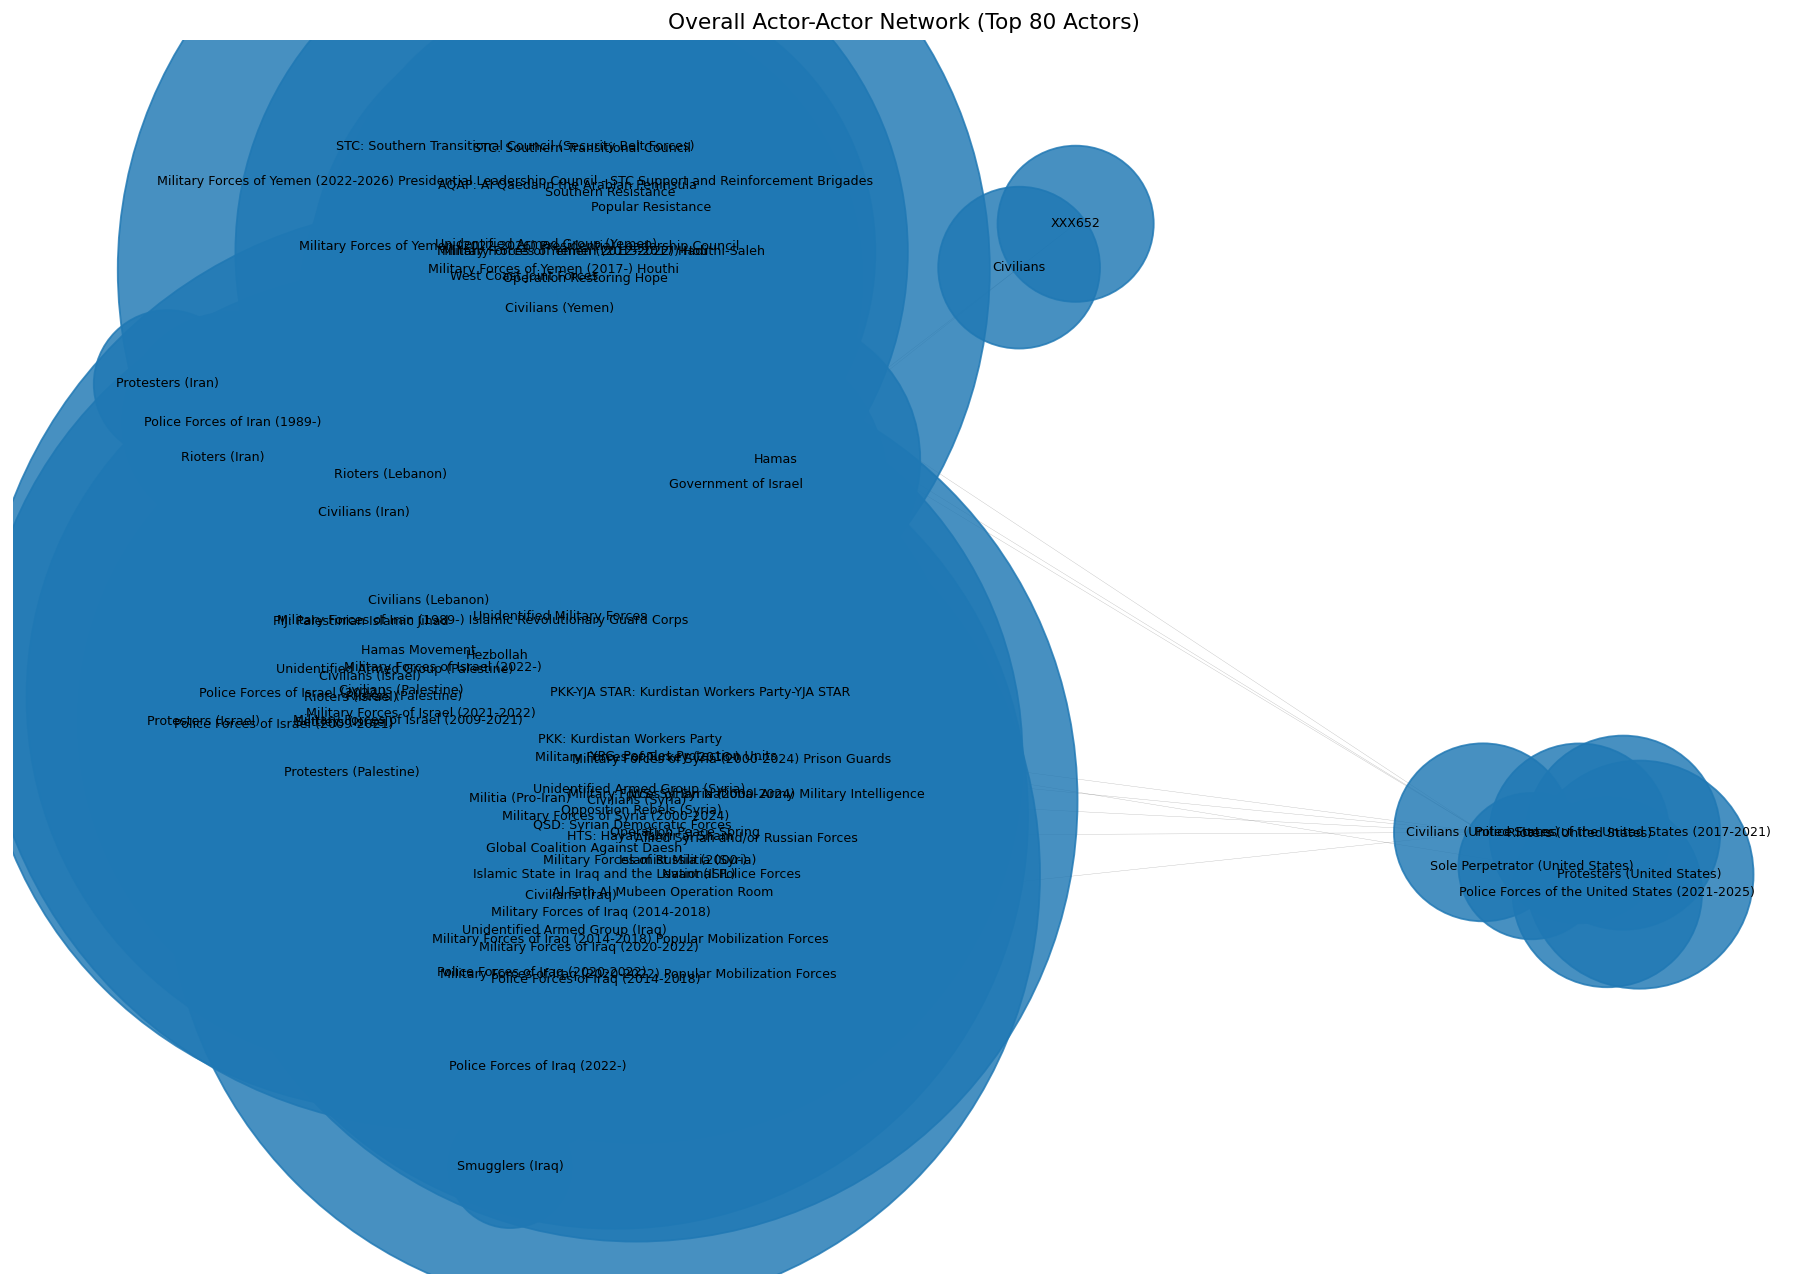

In [22]:
G_overall = build_top_network(overall_edges, overall_node_metrics, top_nodes=80)
print("Overall top-network:", G_overall.number_of_nodes(), "nodes,", G_overall.number_of_edges(), "edges")
draw_network(G_overall, "Overall Actor-Actor Network (Top 80 Actors)")

Phase 1 : 60 nodes, 337 edges


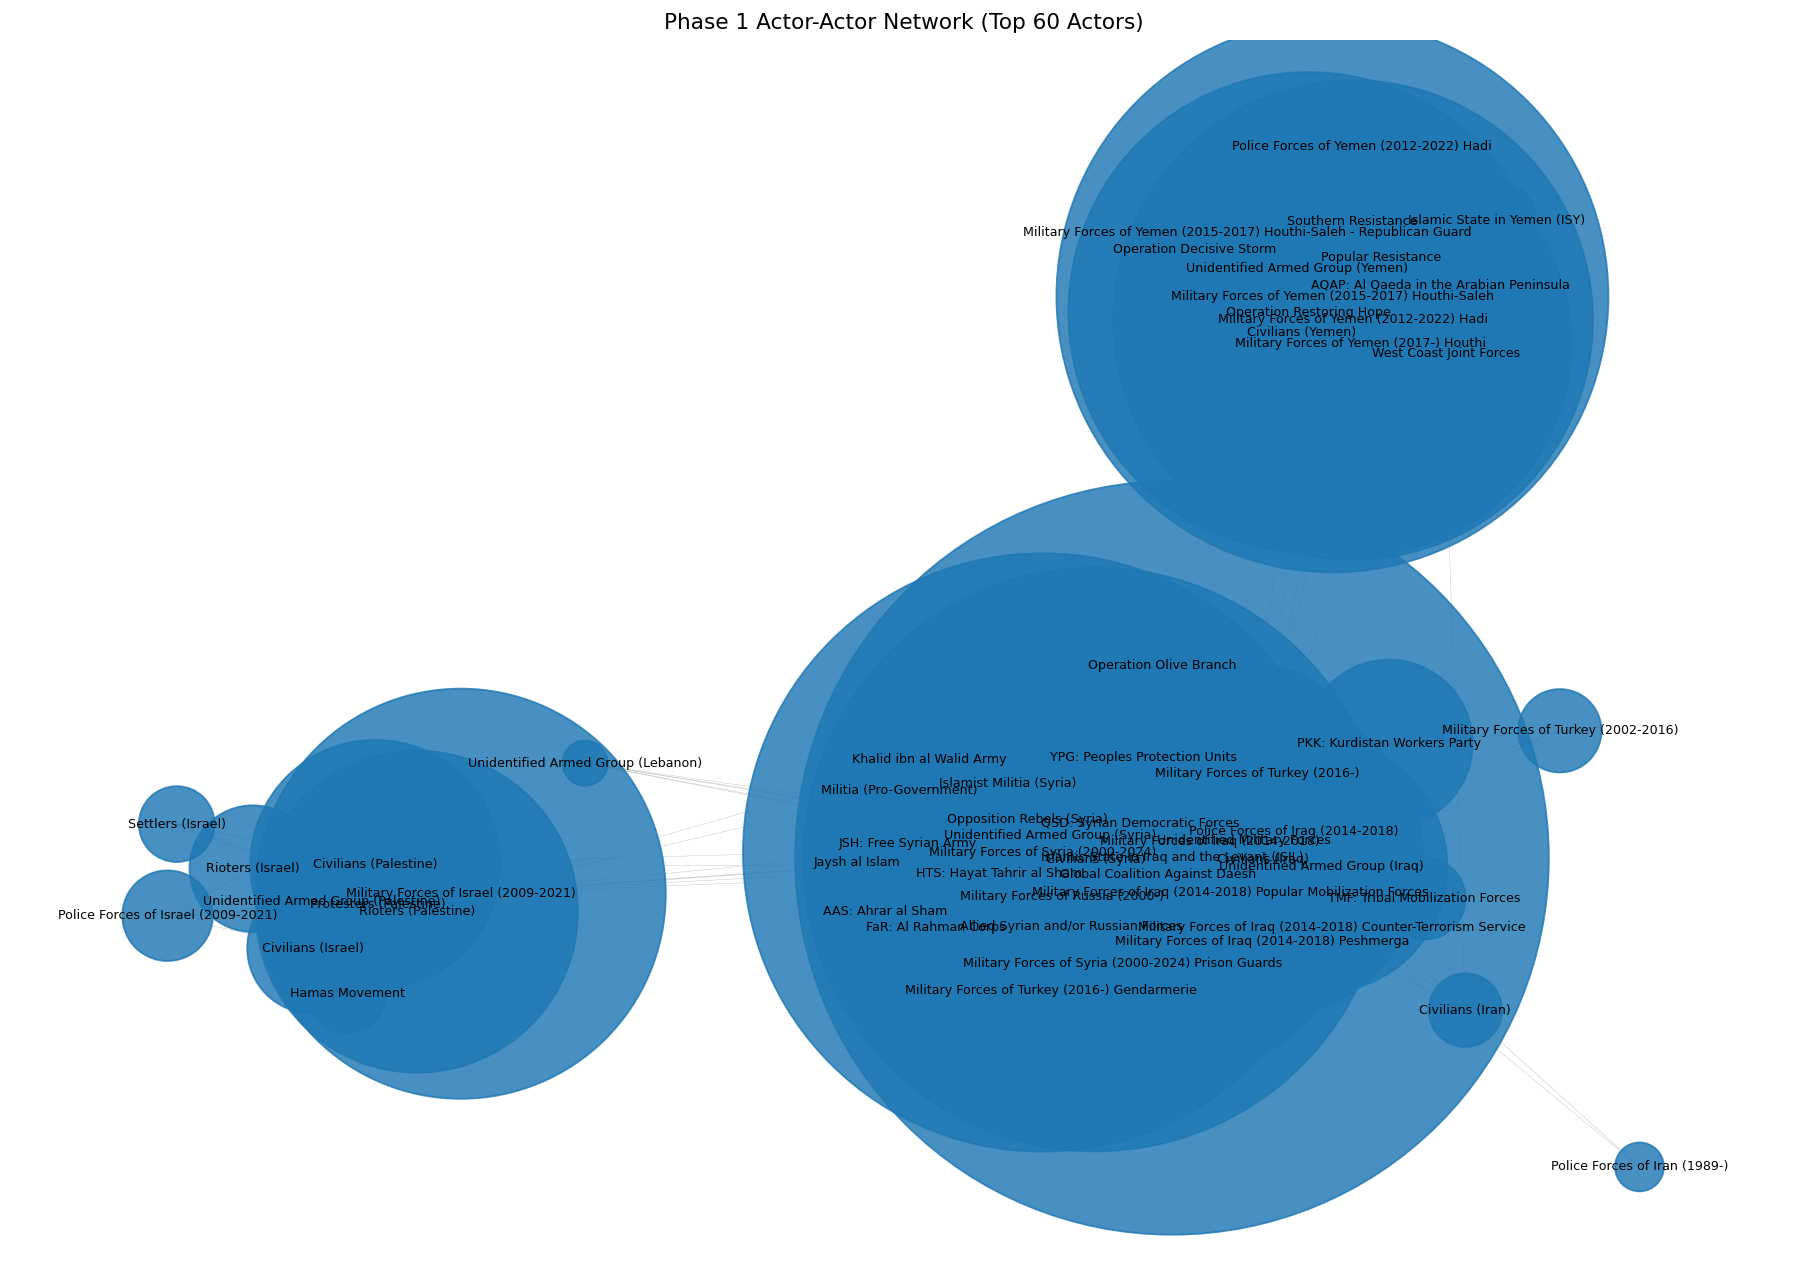

Phase 2 : 60 nodes, 281 edges


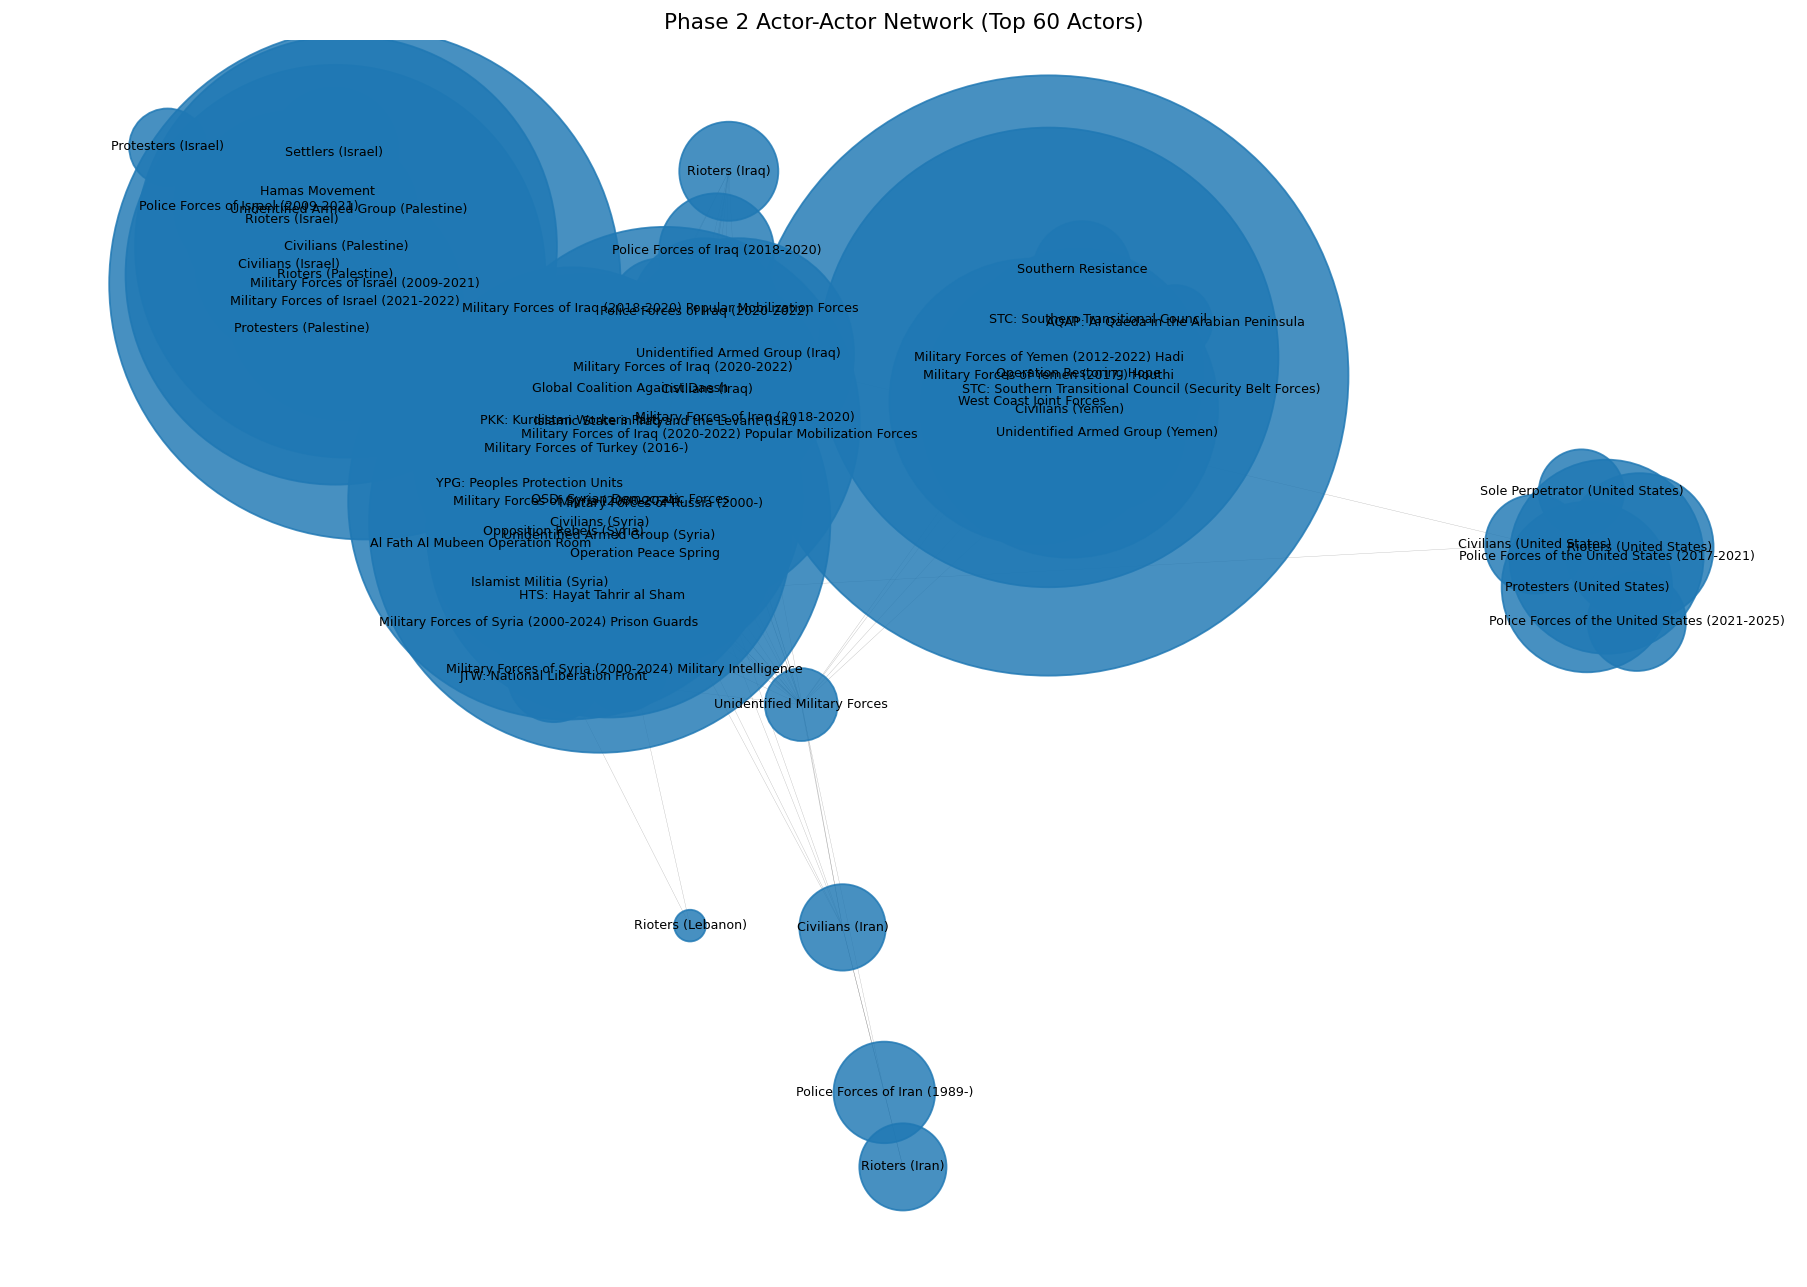

Phase 3 : 60 nodes, 292 edges


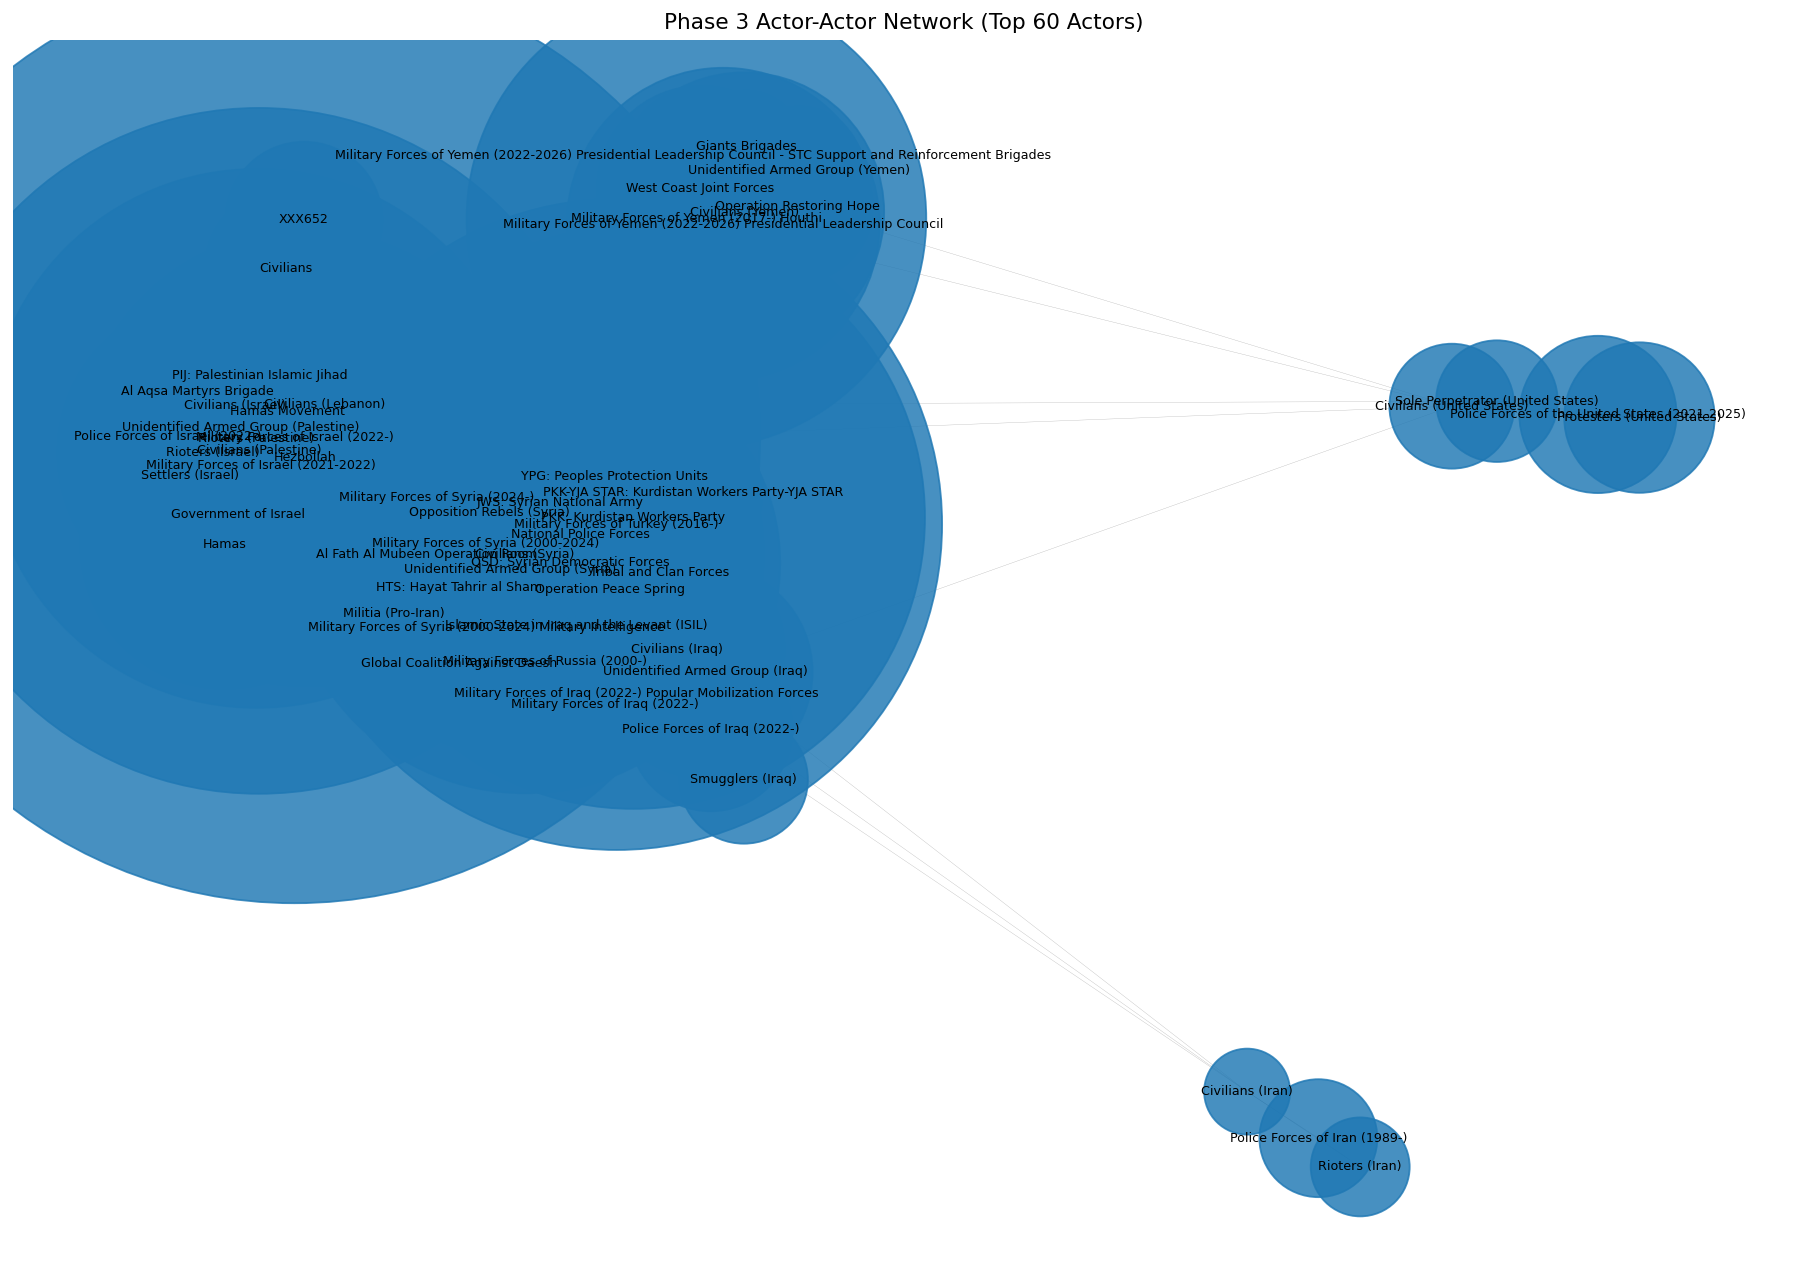

In [23]:
for phase in sorted(phase_edges["phase"].dropna().unique()):
    phase_edge_df = phase_edges[phase_edges["phase"] == phase].copy()
    phase_node_df = phase_node_metrics[phase_node_metrics["phase"] == phase].copy()
    G_phase = build_top_network(phase_edge_df, phase_node_df, top_nodes=60)
    print(phase, ":", G_phase.number_of_nodes(), "nodes,", G_phase.number_of_edges(), "edges")
    draw_network(G_phase, f"{phase} Actor-Actor Network (Top 60 Actors)")

## 8. Bridge-actor visuals

In [24]:
display(overall_bridge.head(15))

,actor,degree,weighted_degree,degree_centrality,betweenness_centrality,eigenvector_centrality,clustering_coefficient,community_id,community_size,bridge_score,is_generic_actor
0,Islamic State in Iraq and the Levant (ISIL),292,34193.0,0.115919,0.076965,0.034190,0.000105,4,275,0.263349,False
1,Military Forces of Yemen (2017-) Houthi,169,32954.0,0.067090,0.065730,0.005891,0.000166,16,505,0.239813,False
2,Military Forces of Israel (2022-),158,35253.0,0.062723,0.042612,0.573357,0.000089,8,235,0.238112,False
3,Military Forces of Syria (2000-2024),199,28631.0,0.079000,0.042617,0.062037,0.000224,46,595,0.203802,False
4,Military Forces of Turkey (2016-),80,22993.0,0.031759,0.016965,0.063860,0.000390,0,39,0.146976,False
5,Military Forces of Yemen (2012-2022) Hadi,93,17711.0,0.036919,0.026156,0.004064,0.000328,16,505,0.123557,False
6,QSD: Syrian Democratic Forces,140,14595.0,0.055578,0.040004,0.030191,0.000269,46,595,0.117919,False
7,Military Forces of Israel (2009-2021),65,16719.0,0.025804,0.012591,0.329343,0.000306,8,235,0.107567,False
8,PKK: Kurdistan Workers Party,35,17836.0,0.013894,0.002209,0.059822,0.000449,0,39,0.105293,False
9,Military Forces of Yemen (2015-2017) Houthi-Saleh,68,12001.0,0.026995,0.012437,0.001518,0.000368,16,505,0.080946,False


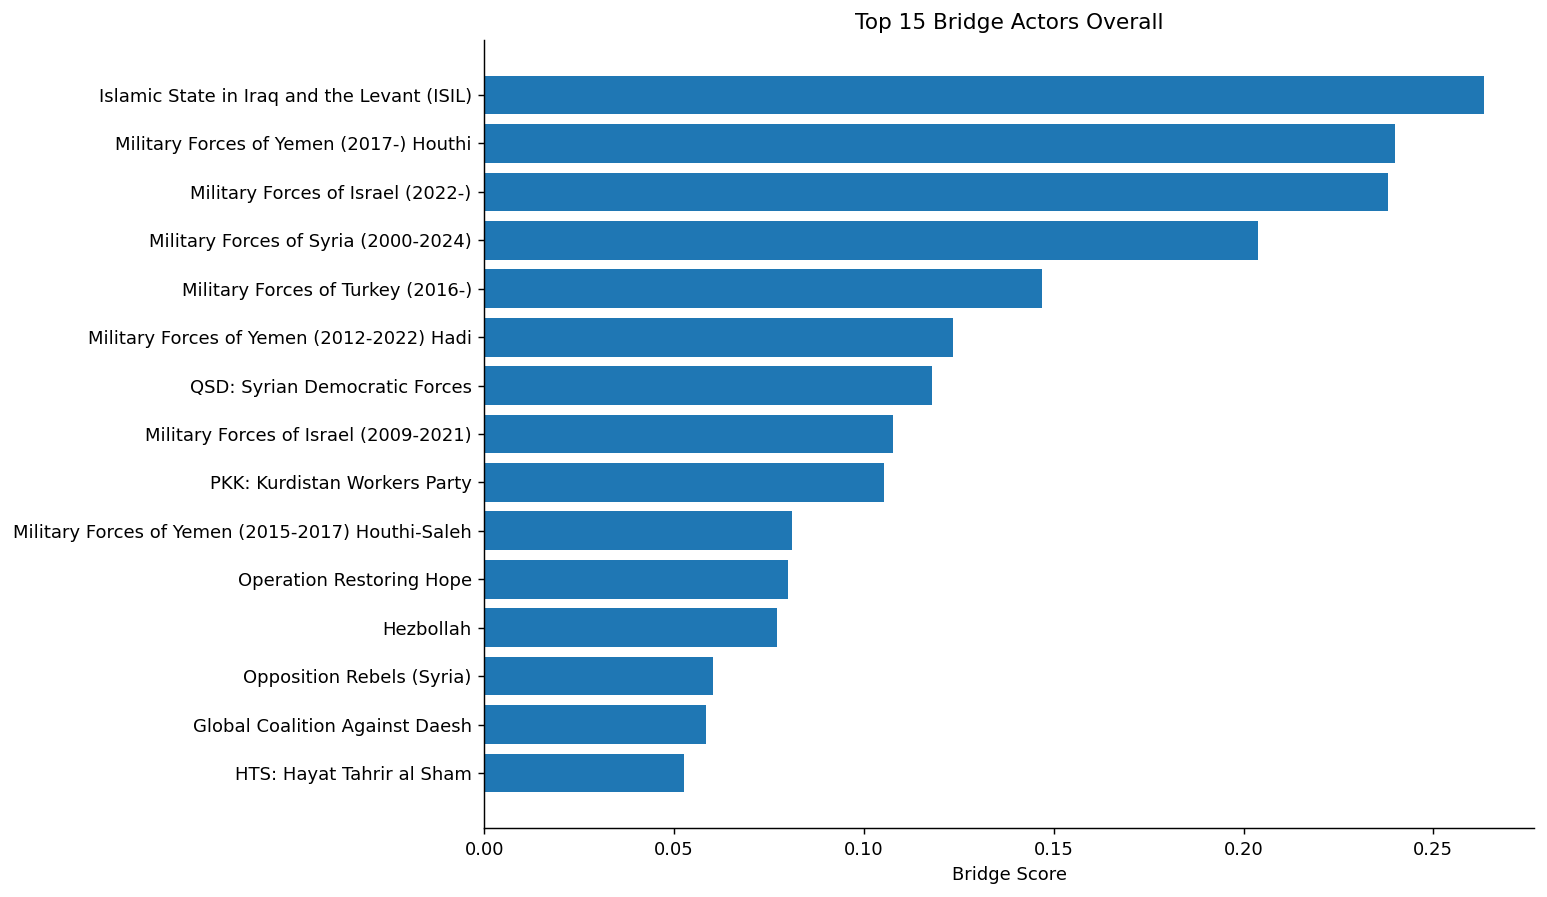

In [25]:
plot_df = overall_bridge[["actor", "bridge_score"]].head(15).iloc[::-1]
plt.figure(figsize=(12, 7))
plt.barh(plot_df["actor"], plot_df["bridge_score"])
plt.title("Top 15 Bridge Actors Overall")
plt.xlabel("Bridge Score")
plt.tight_layout()
plt.show()

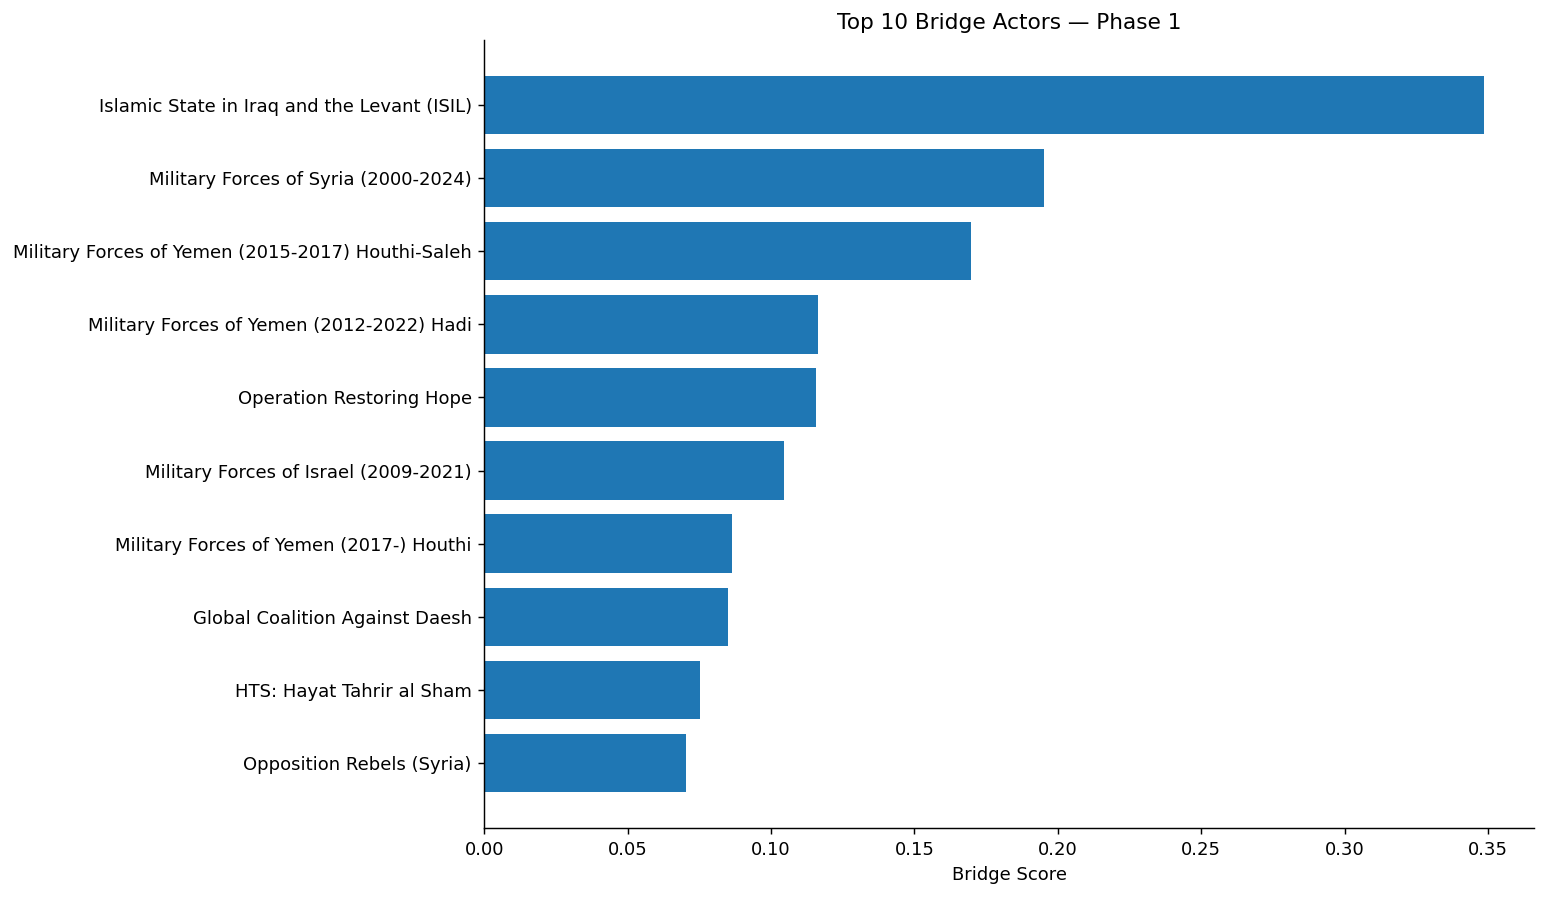

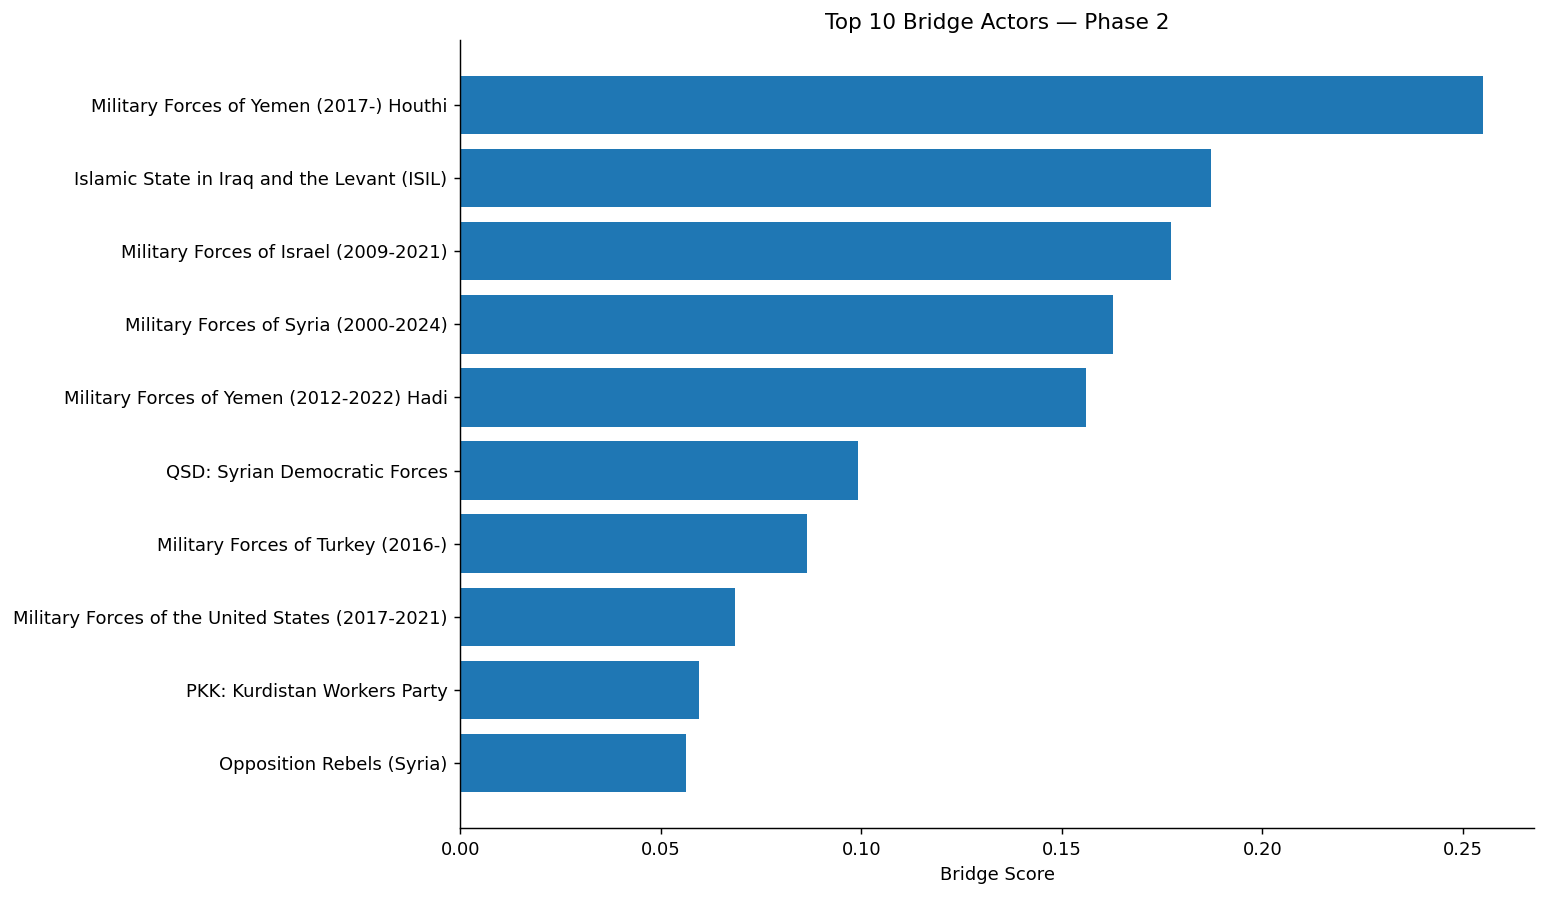

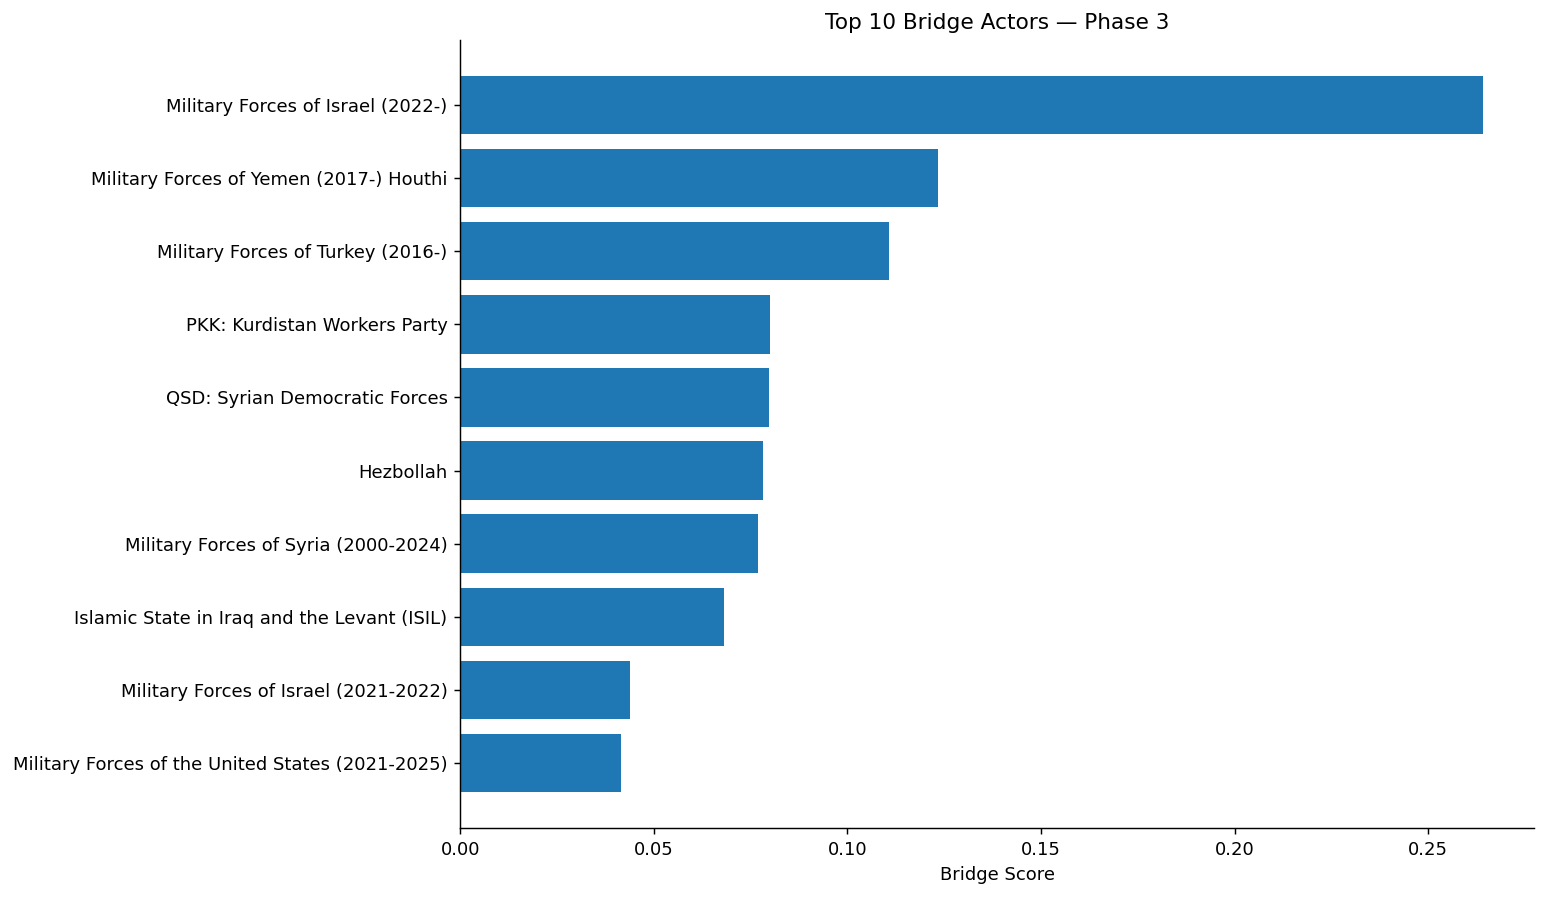

In [26]:
for phase in sorted(phase_bridge["phase"].dropna().unique()):
    plot_df = phase_bridge[phase_bridge["phase"] == phase][["actor", "bridge_score"]].head(10).iloc[::-1]
    plt.figure(figsize=(12, 7))
    plt.barh(plot_df["actor"], plot_df["bridge_score"])
    plt.title(f"Top 10 Bridge Actors — {phase}")
    plt.xlabel("Bridge Score")
    plt.tight_layout()
    plt.show()

,phase,actor,bridge_score
0,Phase 1,Islamic State in Iraq and the Levant (ISIL),0.348656
10,Phase 2,Military Forces of Yemen (2017-) Houthi,0.254951
20,Phase 3,Military Forces of Israel (2022-),0.264109


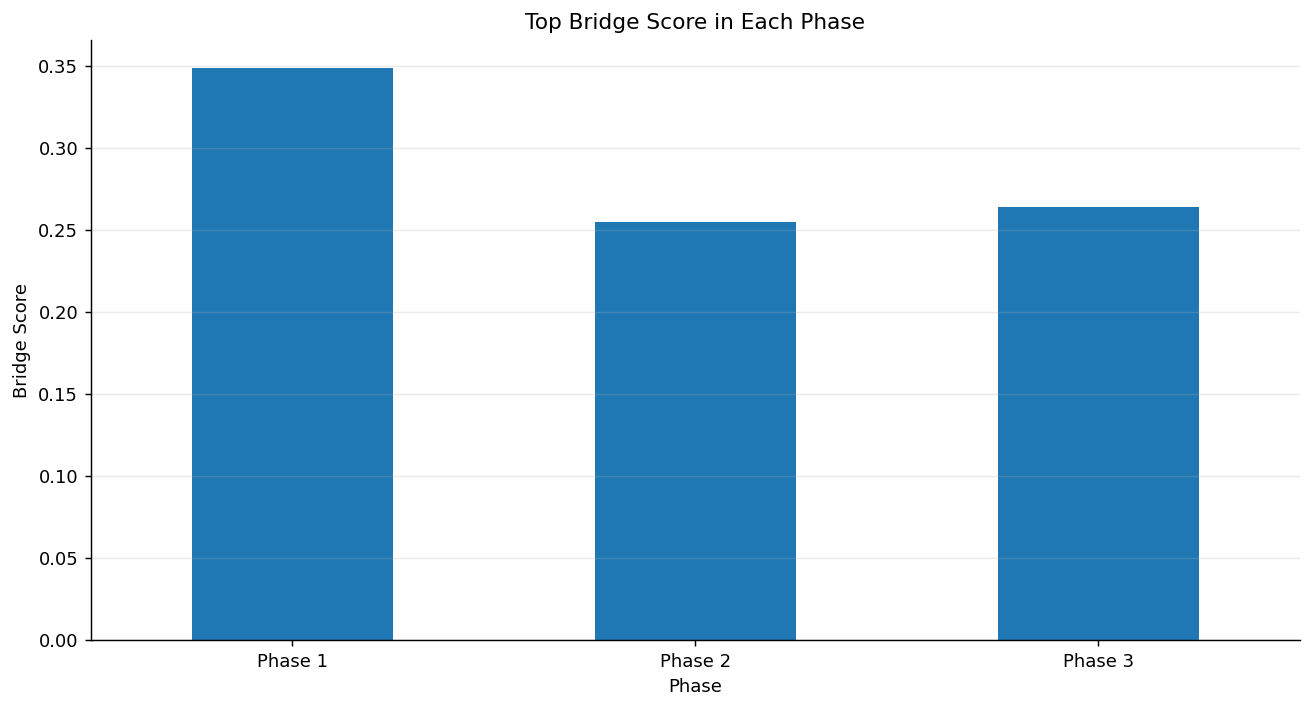

In [27]:
# Bridge score comparison of top actor in each phase
top_bridge_each_phase = (
    phase_bridge.sort_values(["phase", "bridge_score", "betweenness_centrality"], ascending=[True, False, False])
    .groupby("phase")
    .head(1)
    [["phase", "actor", "bridge_score"]]
)
display(top_bridge_each_phase)

ax = top_bridge_each_phase.set_index("phase")["bridge_score"].plot(
    kind="bar", title="Top Bridge Score in Each Phase"
)
ax.set_xlabel("Phase")
ax.set_ylabel("Bridge Score")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()

## 9. Community visuals

In [28]:
display(community_overall.head())
display(community_phase.head())

,community_id,actor_count,avg_degree,avg_weighted_degree,avg_betweenness,total_weighted_degree
0,46,595,6.556303,224.941176,0.001086,133840.0
1,16,505,6.005941,233.956436,0.001283,118148.0
2,4,275,5.821818,288.392727,0.001015,79308.0
3,8,235,6.548936,651.697872,0.001425,153149.0
4,6,85,4.011765,107.047059,0.000928,9099.0


,community_id,actor_count,avg_degree,avg_weighted_degree,avg_betweenness,total_weighted_degree,phase
0,53,218,6.178899,214.688073,0.004427,46802.0,Phase 1
1,11,154,6.240260,319.064935,0.003716,49136.0,Phase 1
2,4,135,4.622222,355.674074,0.003212,48016.0,Phase 1
3,3,45,5.488889,365.466667,0.004017,16446.0,Phase 1
4,10,44,4.409091,23.090909,0.003742,1016.0,Phase 1


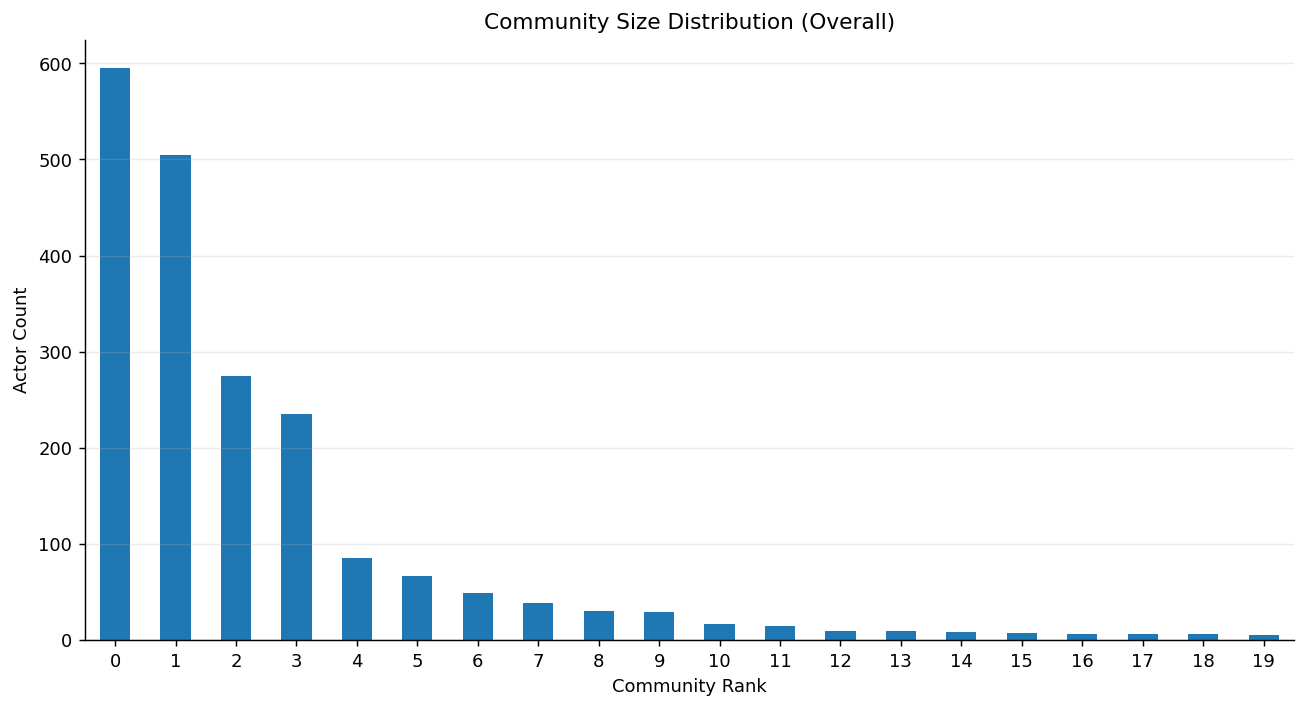

In [29]:
overall_sizes = community_overall.sort_values("actor_count", ascending=False)["actor_count"].head(20).reset_index(drop=True)
ax = overall_sizes.plot(kind="bar", title="Community Size Distribution (Overall)")
ax.set_xlabel("Community Rank")
ax.set_ylabel("Actor Count")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()

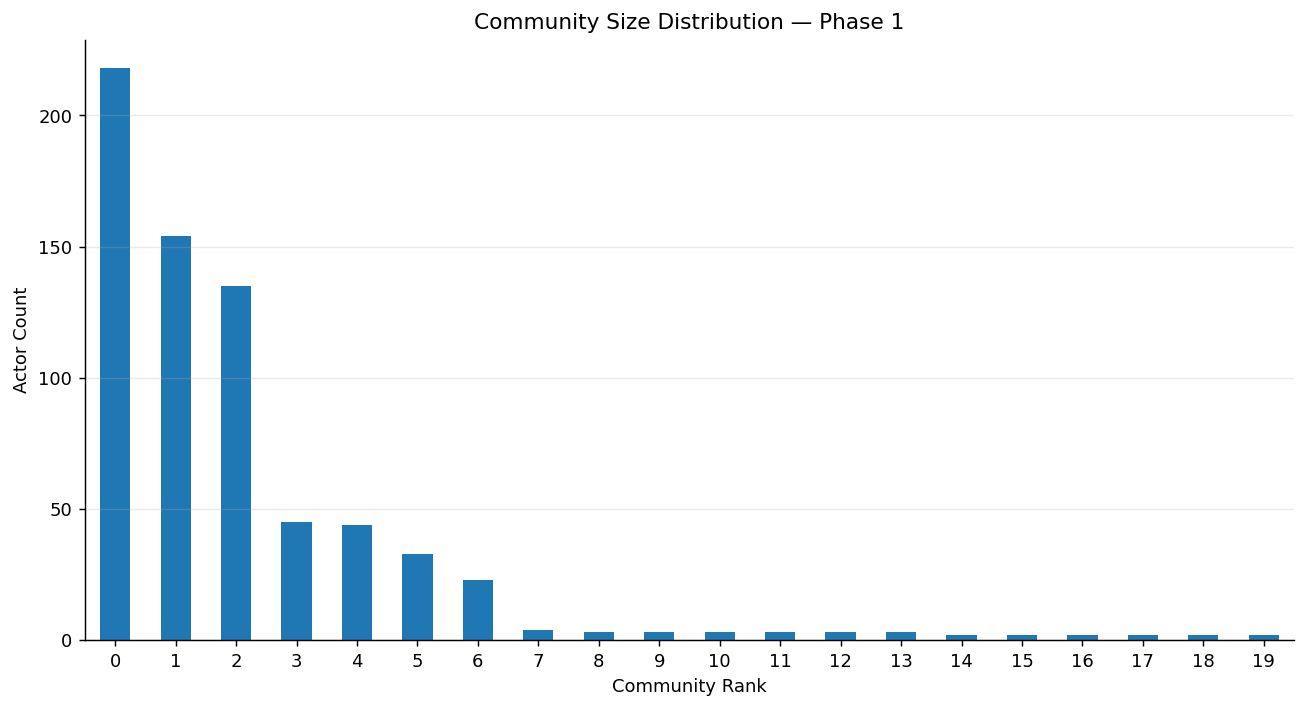

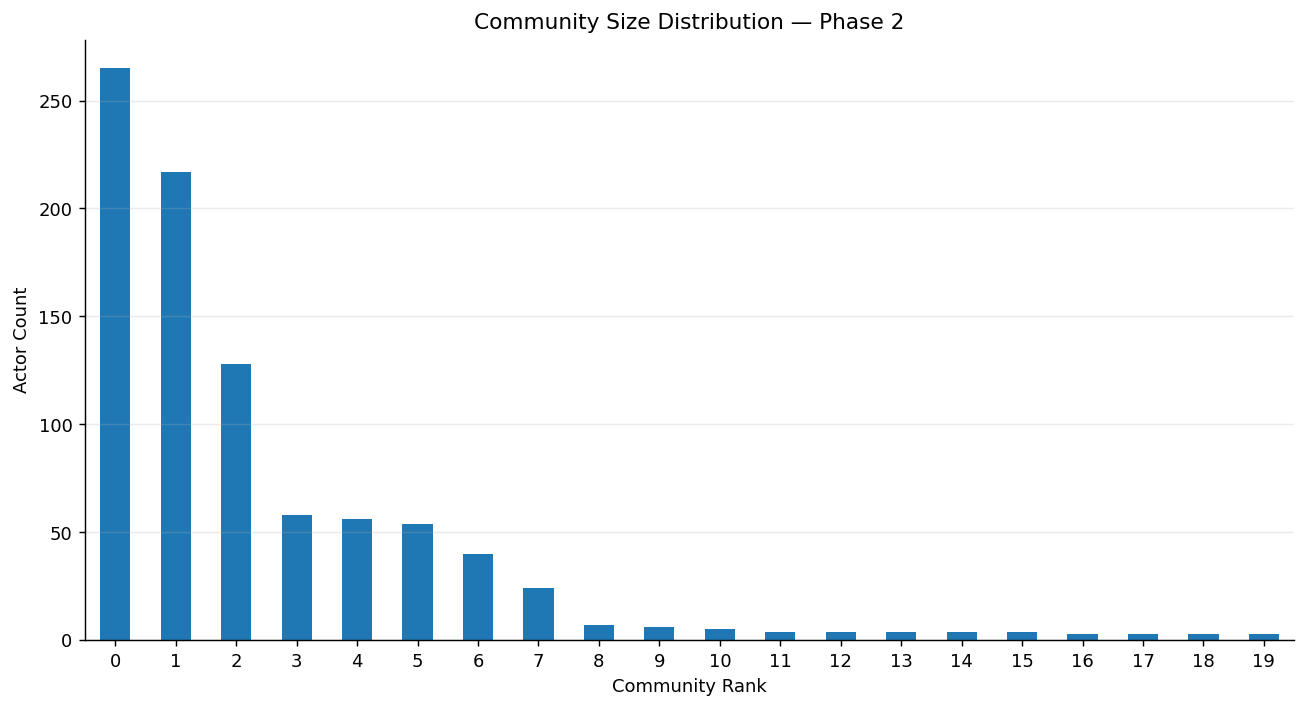

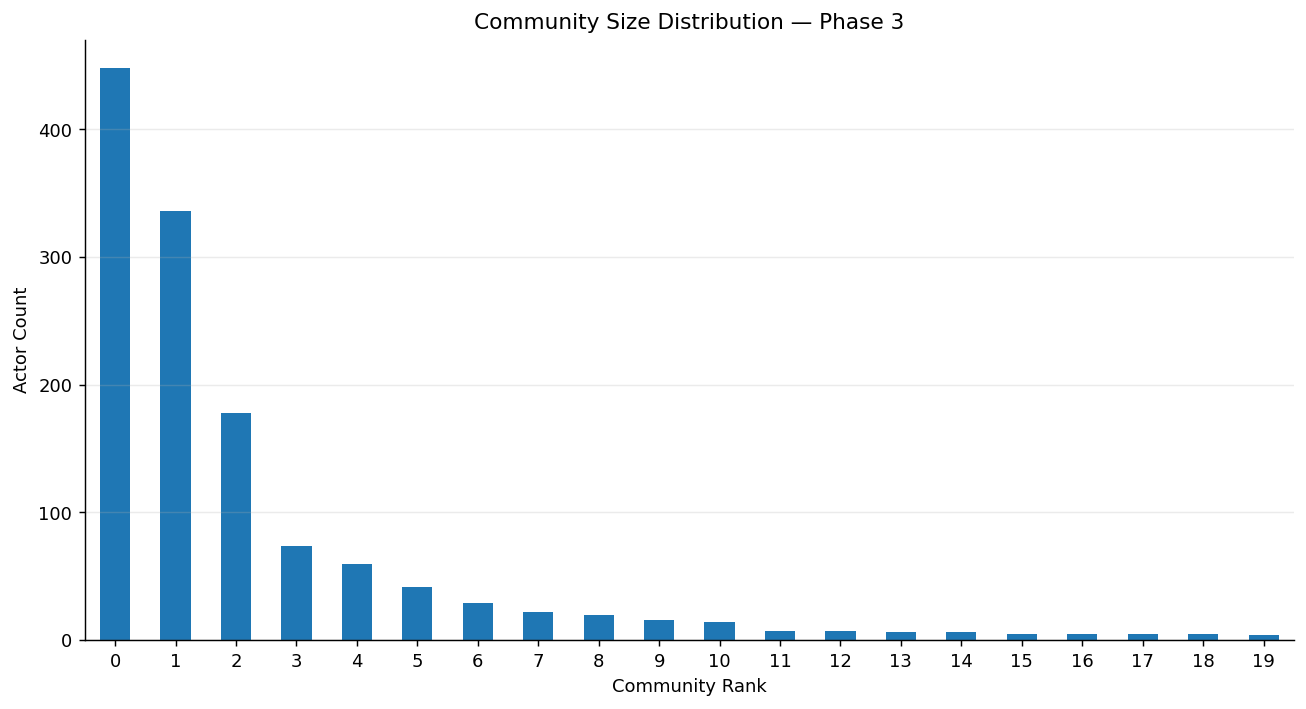

In [30]:
for phase in sorted(community_phase["phase"].dropna().unique()):
    phase_comm = community_phase[community_phase["phase"] == phase].copy()
    sizes = phase_comm.sort_values("actor_count", ascending=False)["actor_count"].head(20).reset_index(drop=True)
    ax = sizes.plot(kind="bar", title=f"Community Size Distribution — {phase}")
    ax.set_xlabel("Community Rank")
    ax.set_ylabel("Actor Count")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.25)
    plt.show()

,phase,nodes,edges,communities,modularity
0,Phase 1,754,1893,54,0.640777
1,Phase 2,1111,2455,125,0.727473
2,Phase 3,1628,3363,179,0.693744


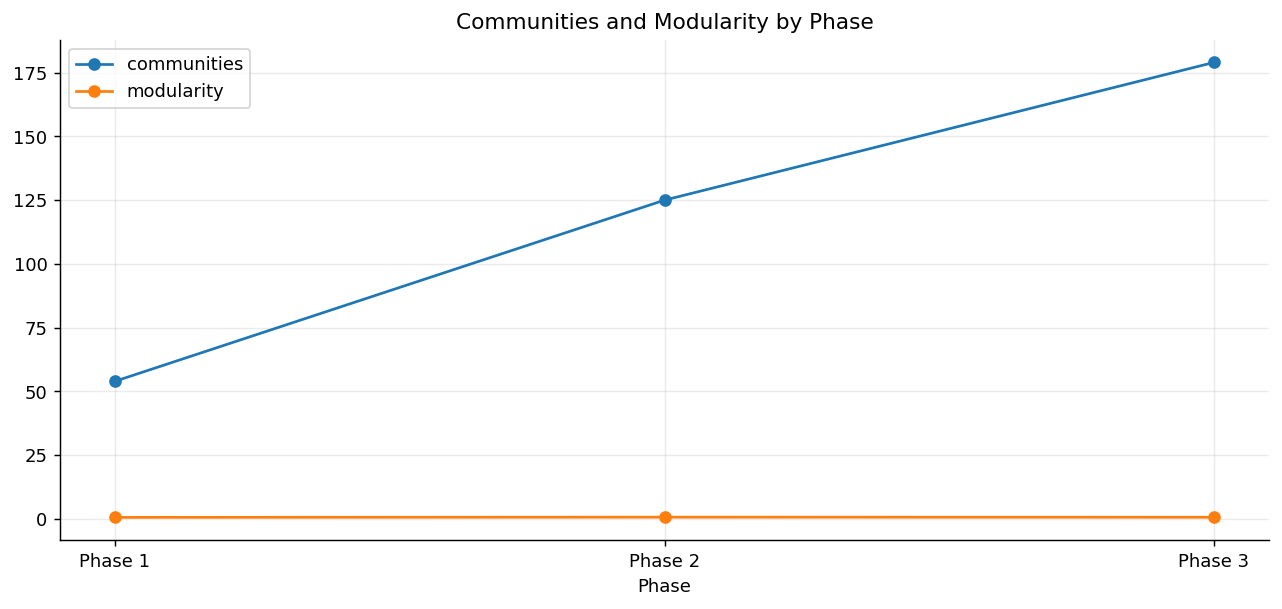

In [31]:
# Communities per phase and modularity
phase_comm_compare = phase_modularity.copy()
display(phase_comm_compare)

plt.figure(figsize=(12,5))
plt.plot(phase_comm_compare["phase"], phase_comm_compare["communities"], marker="o", label="communities")
plt.plot(phase_comm_compare["phase"], phase_comm_compare["modularity"], marker="o", label="modularity")
plt.title("Communities and Modularity by Phase")
plt.xlabel("Phase")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 10. Presentation-ready result tables

In [32]:
summary_table = phase_compare[[
    "phase", "nodes", "edges", "density", "connected_components",
    "largest_component_size", "average_clustering", "communities", "modularity"
]]
display(summary_table)

,phase,nodes,edges,density,connected_components,largest_component_size,average_clustering,communities,modularity
0,Phase 1,754,1893,0.006668,48,652,0.000536,54,0.640777
1,Phase 2,1111,2455,0.003981,107,883,0.000253,125,0.727473
2,Phase 3,1628,3363,0.002539,156,1290,0.000128,179,0.693744


In [33]:
phase_top_bridge = (
    phase_bridge.sort_values(["phase", "bridge_score", "betweenness_centrality"], ascending=[True, False, False])
    .groupby("phase")
    .head(1)
    [["phase", "actor", "bridge_score", "betweenness_centrality", "weighted_degree"]]
    .reset_index(drop=True)
)
display(phase_top_bridge)

,phase,actor,bridge_score,betweenness_centrality,weighted_degree
0,Phase 1,Islamic State in Iraq and the Levant (ISIL),0.348656,0.175604,22643.0
1,Phase 2,Military Forces of Yemen (2017-) Houthi,0.254951,0.066660,14676.0
2,Phase 3,Military Forces of Israel (2022-),0.264109,0.074478,35253.0


In [34]:
phase_top_degree = (
    phase_node_metrics.sort_values(["phase", "weighted_degree", "betweenness_centrality"], ascending=[True, False, False])
    .groupby("phase")
    .head(1)
    [["phase", "actor", "weighted_degree", "betweenness_centrality"]]
    .reset_index(drop=True)
)
display(phase_top_degree)

,phase,actor,weighted_degree,betweenness_centrality
0,Phase 1,Islamic State in Iraq and the Levant (ISIL),22643.0,0.175604
1,Phase 2,Military Forces of Yemen (2017-) Houthi,14676.0,0.066660
2,Phase 3,Military Forces of Israel (2022-),35253.0,0.074478


## 11. Speaking order for presentation

Recommended sequence:

1. Show raw source datasets  
2. Show raw-data plots  
3. Explain harmonization and strict filtering  
4. Show preprocessing retention and country/phase composition  
5. Show phase comparison metrics  
6. Show network graph for each phase  
7. Show bridge actors and community plots  
8. End with summary tables and interpretation